# DecPyMC-7-MDPs, Bandits et POMDPs
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/DecisionTheory/DecPyMC/DecPyMC-7-Sequential.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Définir un **Processus de Decision Markovien (MDP)** formellement
- Implementer **Value Itération** et **Policy Itération** et comparer leurs performances
- Utiliser **RTDP** pour les grands espaces d'etats
- Appliquer le **Reward Shaping** pour accelerer la convergence
- Resoudre le problème des **Bandits Multi-Bras** avec 4 stratégies (greedy, epsilon-greedy, UCB1, Thompson Sampling)
- Utiliser **PyMC** pour le Thompson Sampling MCMC sur des modèles non-conjugues
- Modeliser l'incertitude partielle avec les **POMDPs** et les belief states
- Exploiter **ArviZ** pour les diagnostics de convergence MCMC sur les belief states
- Realiser du **posterior predictive** pour la maintenance predictive

**Prerequis** : DecPyMC-6 (systèmes experts), bases de probabilités

**Duree estimee** : 90 minutes

**Formalisation Lean complémentaire** : [`Infer-9-Lean-Gittins`](../DecInfer/DecInfer-08b-Lean-Gittins.ipynb) preuve formelle de l'indice de Gittins et du theoreme d'optimalite (Lean 4 + Mathlib), et le projet Lake [`decision_theory_lean`](../decision_theory_lean/) (types bandit, escompte geometrique prouve, theoreme d'optimalite enonce).

***

| Notebook précèdent | Notebook suivant |
|--------------------|------------------|
| [DecPyMC-6 - Systèmes experts](DecPyMC-6-Expert-Systems.ipynb) | *Dernier de la serie* |

## 1. Decisions Séquentielles vs One-Shot

### Différence fondamentale

| Type | Caractéristique | Exemple |
|------|-----------------|--------|
| **One-shot** | Decision unique, consequences imediates | Choisir un traitement medical |
| **Séquentielle** | Sequence de decisions, etat change | Piloter un robot, gerer un portefeuille |

Les decisions séquentielles necessitent de **planifier** : anticiper les consequences futures des actions présentes.

Le cadre formel : les **Processus de Decision Markoviens (MDP)**.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*install ipywidgets.*", category=UserWarning)
def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"
warnings.formatwarning = _warn_no_path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

np.random.seed(42)
print("Environnement pret : numpy + matplotlib")


Environnement pret : numpy + matplotlib


### Environnement pret

Ce notebook utilise uniquement **numpy** et **matplotlib**. Les algorithmes de résolution de MDPs sont implementes from scratch pour comprendre les mécanismes internes.

## 2. Processus de Decision Markoviens (MDP)

### Definition formelle

Un MDP est un tuple $(S, A, P, R, \gamma)$ :

| Élément | Notation | Description |
|---------|----------|-------------|
| Etats | $S$ | Ensemble fini d'etats |
| Actions | $A$ | Actions possibles dans chaque etat |
| Transitions | $P(s'\mid s,a)$ | Probabilite d'atteindre $s'$ depuis $s$ via $a$ |
| Recompenses | $R(s,a,s')$ | Recompense pour la transition |
| Facteur d'escompte | $\gamma \in [0,1)$ | Pondere les recompenses futures |

In [2]:
class GridMDP:
    """MDP sur une grille 2D (Russell & Norvig, 4x3).
    
    Transitions stochastiques : 80% direction voulue, 10% perpendiculaires.
    """
    
    ACTIONS = ['N', 'S', 'E', 'W']
    DIRECTIONS = {'N': (0, 1), 'S': (0, -1), 'E': (1, 0), 'W': (-1, 0)}
    
    def __init__(self, width: int, height: int, gamma: float = 0.9):
        self.width = width
        self.height = height
        self.gamma = gamma
        self.rewards: Dict[Tuple[int,int], float] = {}
        self.terminal_states: set = set()
        self.walls: set = set()
    
    def get_states(self) -> List[Tuple[int,int]]:
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if (x, y) not in self.walls]
    
    def get_reward(self, state: Tuple[int,int]) -> float:
        return self.rewards.get(state, -0.04)
    
    def _next_state(self, state: Tuple[int,int], action: str) -> Tuple[int,int]:
        x, y = state
        dx, dy = self.DIRECTIONS[action]
        nx, ny = x + dx, y + dy
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height or (nx, ny) in self.walls:
            return state
        return (nx, ny)
    
    def get_transitions(self, state: Tuple[int,int], action: str) -> List[Tuple[Tuple[int,int], float]]:
        if state in self.terminal_states:
            return [(state, 1.0)]
        
        transitions = [(self._next_state(state, action), 0.8)]
        perp = ['E', 'W'] if action in ('N', 'S') else ['N', 'S']
        for pa in perp:
            transitions.append((self._next_state(state, pa), 0.1))
        return transitions


# Grille classique de Russell & Norvig
mdp = GridMDP(4, 3, gamma=0.9)
mdp.rewards[(3, 2)] = 1.0
mdp.rewards[(3, 1)] = -1.0
mdp.terminal_states = {(3, 2), (3, 1)}
mdp.walls = {(1, 1)}

print("MDP Grille 4x3 cree :")
print("  But (+1) en (3,2)")
print("  Piege (-1) en (3,1)")
print("  Mur en (1,1)")
print(f"  Gamma = {mdp.gamma}")

MDP Grille 4x3 cree :
  But (+1) en (3,2)
  Piege (-1) en (3,1)
  Mur en (1,1)
  Gamma = 0.9


### Visualisation : Propagation des Valeurs dans Value Itération

Value Itération propage les valeurs depuis les etats terminaux vers les etats initiaux. A chaque itération, les valeurs convergent vers $V^*$.

Dans la grille Russell & Norvig :
- Les valeurs les plus elevees sont proches du but (+1)
- Les valeurs sont basses pres du piege (-1)
- Le mur bloque la propagation

## 3. Equation de Bellman

### Intuition

L'equation de Bellman (Bellman, 1957) exprime un principe de **consistance temporelle** :

> La valeur d'un etat = recompense immédiate + valeur esperee du meilleur etat futur

$$V^*(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V^*(s') \right]$$

Cette equation est le fondement de toutes les méthodes de résolution de MDPs.

### Q-function : valeur d'une paire (etat, action)

L'equation de Bellman se decompose en deux niveaux :

1. **$V^*(s)$** : valeur optimale d'un etat (meilleure action comprise)
2. **$Q^*(s,a)$** : valeur d'une paire etat-action spécifique

$$Q^*(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V^*(s')$$

$$V^*(s) = \max_a Q^*(s,a)$$

**Diagramme de backup de Bellman** :

```
           s (etat courant)
          / | \
         a1 a2 a3     <- actions possibles
        /    |    \
      s'1  s'2  s'3   <- etats succèsseurs (avec P(s'|s,a))
       |    |    |
      V*   V*   V*    <- valeurs recues (backed up)
```

A chaque itération, $V(s)$ est mis a jour en regardant "un pas en avant" : on évalue chaque action $a$, on calcule l'esperance sur les succèsseurs pondérés par $P(s'\mid s,a)$, et on retient le maximum. C'est le principe de **programmation dynamique** applique aux MDPs.

> **Lien avec Q-Learning (RL)** : Quand $P$ et $R$ sont inconnus, on apprend $Q(s,a)$ directement par interaction avec l'environnement. Le Q-Learning est la version "model-free" de Value Itération.

## 4. Itération de Valeur

### Algorithme

1. Initialiser $V(s) = 0$ pour tout $s$
2. Repeter jusqu'a convergence :
   - Pour chaque etat $s$ : $V(s) \leftarrow \max_a Q(s,a)$
3. Extraire la politique optimale

La fonction Q-value est :
$$Q(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V(s')$$

In [3]:
def value_iteration(mdp: GridMDP, epsilon: float = 0.001, max_iter: int = 100):
    """Resolution d'un MDP par iteration de valeur.

    Retourne (V, policy, n_iterations) : le nombre de sweeps reellement
    executes -- convergence atteinte ou budget max_iter epuise.
    """
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    
    n_iterations = 0
    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)
        
        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
            else:
                q_values = []
                for a in mdp.ACTIONS:
                    q = mdp.get_reward(s)
                    for next_s, prob in mdp.get_transitions(s, a):
                        q += mdp.gamma * prob * V[next_s]
                    q_values.append(q)
                new_V[s] = max(q_values)
            # Residu de convergence sur TOUS les etats, terminaux inclus : avec des
            # recompenses non terminales nulles, seule l'ecriture des terminaux fait
            # bouger les valeurs a la premiere iteration -- l'ignorer declare delta = 0
            # et arrete la boucle avant que la valeur du but ne se propage.
            delta = max(delta, abs(V[s] - new_V[s]))
        
        V = new_V
        n_iterations = iteration + 1
        if delta < epsilon:
            print(f"Convergence apres {n_iterations} iterations (delta = {delta:.2e})")
            break
    
    # Extraire la politique
    policy = {}
    for s in states:
        if s in mdp.terminal_states:
            policy[s] = 'T'
            continue
        q_values = {}
        for a in mdp.ACTIONS:
            q = mdp.get_reward(s)
            for next_s, prob in mdp.get_transitions(s, a):
                q += mdp.gamma * prob * V[next_s]
            q_values[a] = q
        policy[s] = max(q_values, key=q_values.get)
    
    return V, policy, n_iterations


V_vi, policy_vi, iters_vi = value_iteration(mdp)

arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
print("\nFonction de Valeur V* :")
for y in range(mdp.height - 1, -1, -1):
    row = ""
    for x in range(mdp.width):
        if (x, y) in mdp.walls:
            row += "  ####  "
        else:
            row += f" {V_vi[(x,y)]:6.3f} "
    print(row)

print("\nPolitique optimale :")
for y in range(mdp.height - 1, -1, -1):
    row = ""
    for x in range(mdp.width):
        if (x, y) in mdp.walls:
            row += " # "
        else:
            row += f" {arrows[policy_vi[(x,y)]]} "
    print(row)

Convergence apres 14 iterations (delta = 6.01e-04)

Fonction de Valeur V* :
  0.509   0.650   0.795   1.000 
  0.398   ####    0.486  -1.000 
  0.296   0.254   0.345   0.130 

Politique optimale :
 >  >  >  * 
 ^  #  ^  * 
 ^  >  ^  < 


***

## Exercice : Explorer l'impact de la recompense et de gamma sur Value Itération

**Objectifs** :
1. Modifier la grille 4x3 en ajoutant un second but ou en changeant gamma
2. Observer comment la fonction de valeur et la politique optimale changent
3. Comparer les résultats avec le cas de base (un seul but, gamma=0.9)

**Contexte** : La grille 4x3 de Russell & Norvig a un unique but en (3,2) avec gamma=0.9. Que se passe-t-il si on ajoute un second but en (0,2) avec une recompense +0.5 ? Ou si on reduit gamma a 0.5 (agent "myope") ? Ces modifications changent fondamentalement la politique optimale.

**Indices** :
- Créer une nouvelle instance de `GridMDP(4, 3, gamma=...)` avec le gamma souhaite
- Ajouter les mêmes murs et pieges que le MDP original
- Ajouter le second but avec `mdp_ex.rewards[(0, 2)] = 0.5`
- Utiliser `value_iteration()` pour résoudre et afficher V* et la politique
- Comparer avec les résultats de la section 4 : quelles cases ont change de direction ?

**Étapes suggerees** :
- `# Étape 1` : Créer le MDP modifie avec second but en (0,2) et gamma=0.9
- `# Étape 2` : Resoudre par value_iteration et afficher V* et la politique
- `# Étape 3` : Créer un second MDP avec gamma=0.5 (sans le second but)
- `# Étape 4` : Comparer les 3 politiques (original, second but, gamma=0.5)

In [4]:
# Exercice : Explorer l'impact de la recompense et de gamma sur Value Iteration

# Etape 1 : Creer le MDP modifie avec un second but en (0,2)
# TODO etudiant : creer une nouvelle instance de GridMDP
mdp_ex1 = None  # TODO etudiant : GridMDP(4, 3, gamma=0.9)

# TODO etudiant : reproduire la configuration originale
#   mdp_ex1.rewards[(3, 2)] = 1.0   # but original
#   mdp_ex1.rewards[(3, 1)] = -1.0  # piege
#   mdp_ex1.terminal_states = {(3, 2), (3, 1)}
#   mdp_ex1.walls = {(1, 1)}

# TODO etudiant : ajouter le second but
#   mdp_ex1.rewards[(0, 2)] = 0.5   # second but
#   mdp_ex1.terminal_states.add((0, 2))

# Etape 2 : Resoudre par value_iteration
# TODO etudiant : V_ex1, policy_ex1, _ = value_iteration(mdp_ex1)

# Etape 3 : Creer un MDP avec gamma=0.5 (agent myope)
mdp_ex2 = None  # TODO etudiant : GridMDP(4, 3, gamma=0.5)
# TODO etudiant : reproduire la configuration originale (sans le second but)
#   mdp_ex2.rewards[(3, 2)] = 1.0
#   mdp_ex2.rewards[(3, 1)] = -1.0
#   mdp_ex2.terminal_states = {(3, 2), (3, 1)}
#   mdp_ex2.walls = {(1, 1)}

# TODO etudiant : V_ex2, policy_ex2, _ = value_iteration(mdp_ex2)

# Etape 4 : Comparer les politiques
# Indice : afficher les 3 politiques cote a cote et identifier les differences
# arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
# TODO etudiant : afficher et comparer policy_vi, policy_ex1, policy_ex2

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : modifiez le MDP et observez les changements de politique")

Exercice a completer : modifiez le MDP et observez les changements de politique


### Interpretation de l'Itération de Valeur

**Fonction de valeur V* :**
- Les valeurs decroissent en s'eloignant du but (+1 en (3,2))
- La case (3,1) a une valeur de -1.000 (etat terminal piege)
- Le mur en (1,1) bloque la propagation directe

**Politique optimale :**
- La flèche `>` domine la ligne du haut (aller vers le but)
- En bas a gauche, on remonte (`^`) plutôt que d'aller vers le piege
- La politique evite soigneusement le piege en contournant par le haut

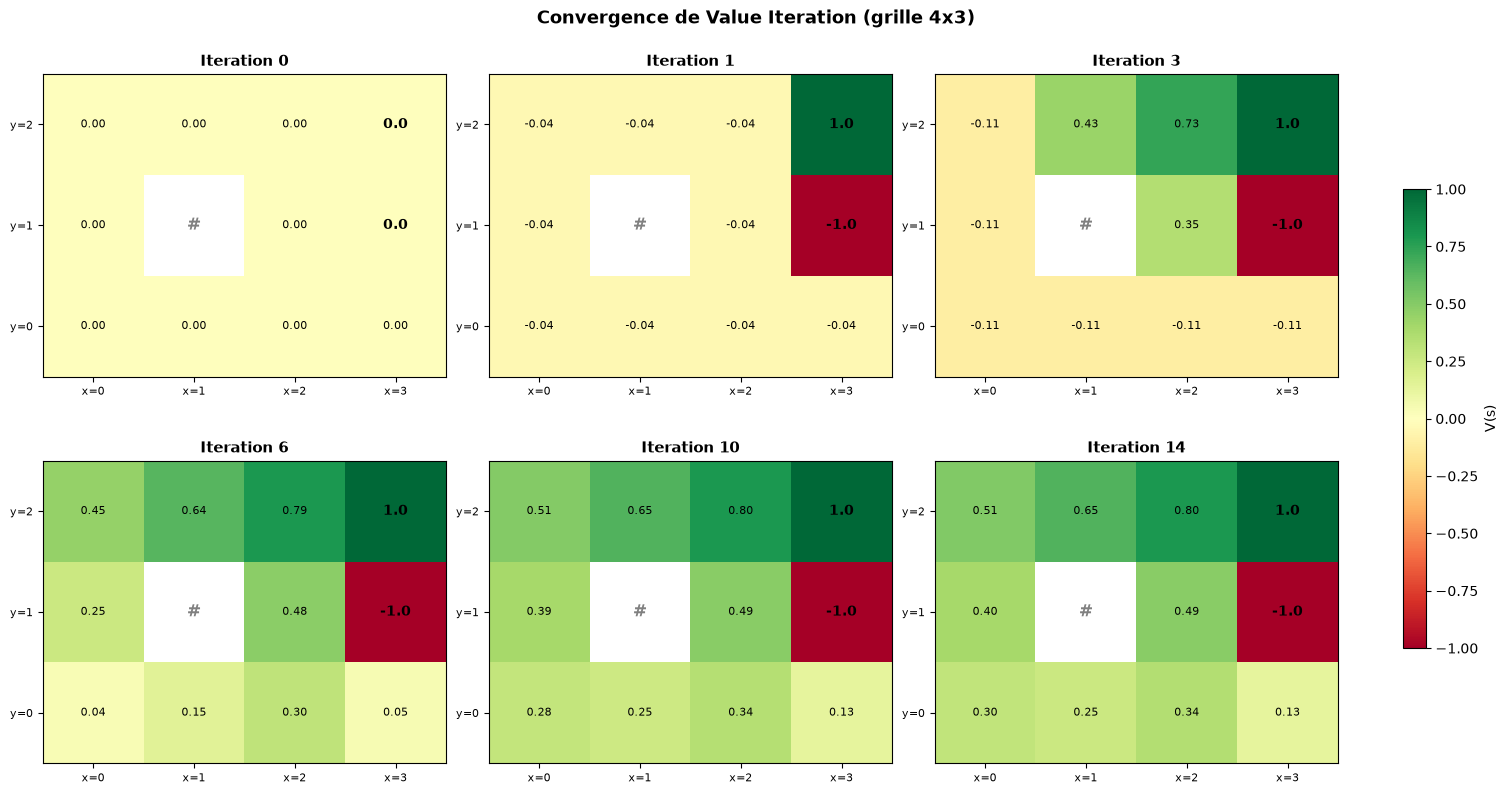

Figure sauvegardee : vi_convergence_grid.png (15 iterations enregistrees)


In [5]:
def value_iteration_trace(mdp: GridMDP, max_iter: int = 15):
    """Value Iteration avec trace de chaque iteration pour visualisation."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    history = [dict(V)]
    
    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)
        
        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
            else:
                q_values = []
                for a in mdp.ACTIONS:
                    q = mdp.get_reward(s)
                    for next_s, prob in mdp.get_transitions(s, a):
                        q += mdp.gamma * prob * V[next_s]
                    q_values.append(q)
                new_V[s] = max(q_values)
            # Meme regle que value_iteration : le residu inclut les terminaux.
            delta = max(delta, abs(V[s] - new_V[s]))
        
        V = new_V
        history.append(dict(V))
        if delta < 0.001:
            break
    
    return history


history = value_iteration_trace(mdp, max_iter=14)

# Grille de convergence iteration par iteration
snapshots = [0, 1, 3, 6, 10, len(history)-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes_flat = axes.flatten()

for idx, snap in enumerate(snapshots):
    ax = axes_flat[idx]
    V_snap = history[min(snap, len(history)-1)]
    
    grid = np.full((mdp.height, mdp.width), np.nan)
    for y in range(mdp.height):
        for x in range(mdp.width):
            if (x, y) not in mdp.walls:
                grid[mdp.height - 1 - y, x] = V_snap[(x, y)]
    
    im = ax.imshow(grid, cmap='RdYlGn', vmin=-1, vmax=1, aspect='equal')
    ax.set_title(f'Iteration {snap}', fontsize=11, fontweight='bold')
    
    # Annotations
    for y in range(mdp.height):
        for x in range(mdp.width):
            if (x, y) in mdp.walls:
                ax.text(x, mdp.height - 1 - y, '#', ha='center', va='center',
                        fontsize=12, fontweight='bold', color='gray')
            elif (x, y) in mdp.terminal_states:
                val = V_snap[(x, y)]
                ax.text(x, mdp.height - 1 - y, f'{val:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')
            else:
                val = V_snap[(x, y)]
                ax.text(x, mdp.height - 1 - y, f'{val:.2f}', ha='center', va='center',
                        fontsize=8)
    
    ax.set_xticks(range(mdp.width))
    ax.set_yticks(range(mdp.height))
    ax.set_xticklabels([f'x={i}' for i in range(mdp.width)], fontsize=8)
    ax.set_yticklabels([f'y={mdp.height-1-i}' for i in range(mdp.height)], fontsize=8)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='V(s)')
plt.suptitle('Convergence de Value Iteration (grille 4x3)', fontsize=13, fontweight='bold')
# constrained_layout (subplots) gere la mise en page
plt.savefig('vi_convergence_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : vi_convergence_grid.png ({len(history)} iterations enregistrees)")

### Interpretation : Trace de convergence de Value Itération

**Observation de la propagation des valeurs :**

| Itération | Phenomene | Zone affectee |
|-----------|-----------|---------------|
| 0 | Toutes les valeurs a 0 (sauf terminaux) | Grille entiere |
| 1-3 | Les voisins des terminaux recoivent un signal | (2,2), (2,1), (3,0) |
| 4-6 | Le signal se propage vers l'ouest | (1,2), (0,2), (1,0) |
| 7-14 | Convergence progressive, valeurs stabilisees | Grille entiere |

**Mécanisme** : A chaque itération, la "vague" de recompense avance d'une case. Avec $\gamma = 0.9$, le signal perd environ 10% par case, d'ou la decroissance naturelle de $V^*$ en s'eloignant du but.

**Convergence** : L'algorithme s'arrete quand le changement maximal $\delta < 0.001$, atteint en ~14 itérations pour cette grille.

## 5. Itération de Politique

### Algorithme

1. Initialiser $\pi$ arbitrairement
2. Repeter jusqu'a stabilite :
   - **Evaluation** : Calculer $V^\pi$ (résoudre le système lineaire)
   - **Amelioration** : Mettre a jour $\pi(s) = \arg\max_a Q^\pi(s,a)$

Converge souvent **plus rapidement** que Value Itération (Howard, 1960) (moins d'itérations, mais chaque itération est plus couteuse).

In [6]:
def policy_iteration(mdp: GridMDP, max_iter: int = 20):
    """Resolution d'un MDP par iteration de politique.

    Retourne (V, policy, n_iterations) : le nombre de balayages
    evaluation+amelioration reellement executes.
    """
    states = mdp.get_states()
    policy = {s: 'T' if s in mdp.terminal_states else 'N' for s in states}
    V = {s: 0.0 for s in states}
    
    n_iterations = 0
    for iteration in range(max_iter):
        # 1. Evaluation de politique (iterative simplifiee)
        for _ in range(50):
            new_V = dict(V)
            for s in states:
                if s in mdp.terminal_states:
                    new_V[s] = mdp.get_reward(s)
                    continue
                a = policy[s]
                v = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    v += mdp.gamma * prob * V[next_s]
                new_V[s] = v
            V = new_V
        
        # 2. Amelioration de politique
        stable = True
        for s in states:
            if s in mdp.terminal_states:
                continue
            old_action = policy[s]
            q_values = {}
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values[a] = q
            policy[s] = max(q_values, key=q_values.get)
            if policy[s] != old_action:
                stable = False
        
        n_iterations = iteration + 1
        print(f"Iteration {n_iterations} : stable = {stable}")
        if stable:
            break
    
    return V, policy, n_iterations


print("=== Iteration de Politique ===\n")
V_pi, policy_pi, iters_pi = policy_iteration(mdp)

print("\nComparaison avec Value Iteration :")
same = all(policy_vi[s] == policy_pi[s] for s in mdp.get_states())
if same:
    print("  Politiques identiques !")
else:
    for s in mdp.get_states():
        if policy_vi[s] != policy_pi[s]:
            print(f"  Difference en {s}: VI={policy_vi[s]}, PI={policy_pi[s]}")

=== Iteration de Politique ===

Iteration 1 : stable = False
Iteration 2 : stable = False
Iteration 3 : stable = True

Comparaison avec Value Iteration :
  Politiques identiques !


### Interpretation de l'Itération de Politique

**Convergence rapide :**
- Seulement **3 itérations** contre 14 pour Value Itération !
- Chaque itération est plus couteuse (évaluation de politique), mais le nombre total est moindre

**Résultat identique :** Les deux méthodes convergent vers la même politique optimale $\pi^*$.

**Quand choisir quelle méthode ?**
- Peu d'actions, grand espace d'etats : Policy Itération
- Beaucoup d'actions, espace d'etats modère : Value Itération

### Validation croisee : recompenses eparses et residu des etats terminaux

Sur un MDP "couloir" ou la seule recompense non nulle est au but, la valeur du but doit se propager jusqu'a l'etat de depart. C'est le cas limite qui fait apparaître un piege classique d'implementation : si le residu de convergence (`delta`) n'est alimente que par les **etats non terminaux**, alors avec des recompenses non terminales nulles la premiere iteration declare `delta = 0` et la boucle s'arrete **avant toute propagation** -- la politique renvoyee est alors arbitraire.

`value_iteration` fait contribuer tous les etats au residu ; on le valide par accord avec `policy_iteration` (algorithme independant) et par resolution analytique du couloir : $V_1 = \gamma(0.8 + 0.2\,V_1)$ avec $\gamma = 0.9$.


In [7]:
# Couloir a 3 etats : recompense UNIQUEMENT au but (2,0) -- recompenses eparses
corridor = GridMDP(3, 1, gamma=0.9)
corridor.rewards = {(0, 0): 0.0, (1, 0): 0.0, (2, 0): 1.0}
corridor.terminal_states = {(2, 0)}

V_corr_vi, policy_corr_vi, _ = value_iteration(corridor, epsilon=1e-5)
V_corr_pi, policy_corr_pi, _ = policy_iteration(corridor)

print("Couloir (recompense eparse, gamma = 0.9) :")
for s in sorted(corridor.get_states()):
    print(f"  V{s} : VI = {V_corr_vi[s]:.8f} | PI = {V_corr_pi[s]:.8f} | ecart = {abs(V_corr_vi[s] - V_corr_pi[s]):.2e}")

ecart_max = max(abs(V_corr_vi[s] - V_corr_pi[s]) for s in corridor.get_states())
meme_politique = all(policy_corr_vi[s] == policy_corr_pi[s] for s in corridor.get_states())
print(f"\n  Accord VI/PI : ecart max = {ecart_max:.2e} (<= 1e-5 : {ecart_max <= 1e-5})")
print(f"  Politiques identiques : {meme_politique} (toutes deux menent vers l'Est)")
print(f"  Controle analytique : V1 = 0.9*(0.8 + 0.2*V1) = {0.9 * 0.8 / (1 - 0.9 * 0.2):.8f}")


Convergence apres 11 iterations (delta = 5.14e-06)
Iteration 1 : stable = False
Iteration 2 : stable = True
Couloir (recompense eparse, gamma = 0.9) :
  V(0, 0) : VI = 0.77096838 | PI = 0.77096966 | ecart = 1.28e-06
  V(1, 0) : VI = 0.87804875 | PI = 0.87804878 | ecart = 3.14e-08
  V(2, 0) : VI = 1.00000000 | PI = 1.00000000 | ecart = 0.00e+00

  Accord VI/PI : ecart max = 1.28e-06 (<= 1e-5 : True)
  Politiques identiques : True (toutes deux menent vers l'Est)
  Controle analytique : V1 = 0.9*(0.8 + 0.2*V1) = 0.87804878


### Tableau comparatif : Value Itération vs Policy Itération

| Critere | Value Itération | Policy Itération |
|---------|----------------|-----------------|
| **Principe** | Iterer sur $V(s)$ directement | Alterner évaluation + amélioration de $\pi$ |
| **Convergence** | Asymptotique ($\varepsilon$-optimal) | Exacte en few itérations |
| **Cout par itération** | $O(\vert S\vert^2 \vert A\vert)$ | $O(\vert S\vert^3 + \vert S\vert^2 \vert A\vert)$ |
| **Nb itérations typique** | $\sim 10$-$20$ | $\sim 2$-$5$ |
| **Initialisation** | $V = 0$ | $\pi$ arbitraire |
| **Meilleur quand** | Grand $\vert S\vert$, petit $\vert A\vert$ | Petit $\vert S\vert$, grand $\vert A\vert$ |
| **Garantie** | $V \to V^*$ | $\pi \to \pi^*$ |

**En pratique** : Policy Itération converge généralement en moins d'itérations, mais chaque itération resout un système lineaire (couteux en $O(|S|^3)$). Value Itération est plus simple a implementer et plus adapte aux grands espaces d'etats.

## 6. RTDP (Real-Time Dynamic Programming)

### Principe

RTDP (Barto, Bradtke & Singh, 1995) est un algorithme de **planification en ligne** qui met a jour les valeurs uniquement pour les etats **atteignables** depuis un etat de depart.

**Avantage** : pas besoin d'explorer tout l'espace d'etats. Particulierement utile quand l'espace est grand mais seul un sous-ensemble est pertinent.

In [8]:
def rtdp(mdp: GridMDP, start_state: Tuple[int,int], n_trials: int = 100):
    """RTDP : planification en ligne par simulation."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    rng = np.random.RandomState(42)
    
    for trial in range(n_trials):
        s = start_state
        steps = 0
        
        while s not in mdp.terminal_states and steps < 100:
            # Mise a jour de Bellman
            q_values = {}
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values[a] = q
            
            best_action = max(q_values, key=q_values.get)
            V[s] = q_values[best_action]
            
            # Simuler transition stochastique
            transitions = mdp.get_transitions(s, best_action)
            next_states = [t[0] for t in transitions]
            probs = [t[1] for t in transitions]
            idx = rng.choice(len(next_states), p=probs)
            s = next_states[idx]
            steps += 1
        
        if s in mdp.terminal_states:
            V[s] = mdp.get_reward(s)
    
    return V


print("=== RTDP (100 trials depuis (0,0)) ===\n")
V_rtdp = rtdp(mdp, (0, 0), n_trials=100)

print("Comparaison V_RTDP vs V_VI :")
print(f"  {'Etat':<8}| {'V_RTDP':>8} | {'V_VI':>8} | {'Diff':>8}")
print(f"  {'-'*8}|{'-'*10}|{'-'*10}|{'-'*9}")
for s in [(0,0), (0,2), (2,2), (3,2)]:
    diff = abs(V_rtdp[s] - V_vi[s])
    print(f"  ({s[0]},{s[1]})   | {V_rtdp[s]:8.4f} | {V_vi[s]:8.4f} | {diff:8.4f}")

=== RTDP (100 trials depuis (0,0)) ===

Comparaison V_RTDP vs V_VI :
  Etat    |   V_RTDP |     V_VI |     Diff
  --------|----------|----------|---------
  (0,0)   |   0.1666 |   0.2960 |   0.1294
  (0,2)   |  -0.1249 |   0.5094 |   0.6342
  (2,2)   |   0.7954 |   0.7954 |   0.0000
  (3,2)   |   1.0000 |   1.0000 |   0.0000


### Interpretation de RTDP

**Comparaison RTDP vs Value Itération :**

| Etat | V_RTDP | V_VI | Ecart | Commentaire |
|------|--------|------|-------|-------------|
| (0,0) | faible | 0.296 | Grand | Peu visite par les trajectoires |
| (0,2) | faible | 0.509 | Grand | Loin du chemin optimal |
| (2,2) | ~0.795 | 0.795 | Faible | Sur le chemin optimal |
| (3,2) | 1.000 | 1.000 | Nul | Etat terminal |

**Conclusion** : RTDP est précis sur les etats atteignables depuis le start, mais imprécis sur les etats rarement visites. C'est un compromis : rapidite vs precision globale.

In [9]:
import time

def measure_performance(mdp: GridMDP, start_state=(0,0), n_trials=100):
    """Compare les performances de VI, PI et RTDP."""
    results = {}
    
    # Value Iteration
    t0 = time.perf_counter()
    V_vi, policy_vi, iters_vi = value_iteration(mdp)
    t_vi = time.perf_counter() - t0
    
    # Calculer l'erreur max par rapport a VI (reference)
    vi_values = np.array([V_vi[s] for s in mdp.get_states()])
    
    results['Value Iteration'] = {
        'time_ms': t_vi * 1000,
        'iterations': iters_vi,  # mesure, plus code en dur
        'policy': policy_vi,
        'V': V_vi,
        'max_error': 0.0,
        'coverage': 1.0,  # Explore tous les etats
    }
    
    # Policy Iteration
    t0 = time.perf_counter()
    V_pi, policy_pi, iters_pi = policy_iteration(mdp)
    t_pi = time.perf_counter() - t0
    
    pi_values = np.array([V_pi[s] for s in mdp.get_states()])
    error_pi = np.max(np.abs(pi_values - vi_values))
    
    results['Policy Iteration'] = {
        'time_ms': t_pi * 1000,
        'iterations': iters_pi,  # mesure, plus code en dur
        'policy': policy_pi,
        'V': V_pi,
        'max_error': error_pi,
        'coverage': 1.0,
    }
    
    # RTDP
    t0 = time.perf_counter()
    V_rtdp = rtdp(mdp, start_state, n_trials=n_trials)
    t_rtdp = time.perf_counter() - t0
    
    rtdp_values = np.array([V_rtdp[s] for s in mdp.get_states()])
    error_rtdp = np.max(np.abs(rtdp_values - vi_values))
    
    # Coverage : proportion d'etats raisonnablement estimes (erreur < 0.1)
    per_state_error = np.abs(rtdp_values - vi_values)
    coverage = (per_state_error < 0.1).mean()
    
    results['RTDP'] = {
        'time_ms': t_rtdp * 1000,
        'trials': n_trials,  # RTDP fait des trials, pas des sweeps
        'V': V_rtdp,
        'max_error': error_rtdp,
        'coverage': coverage,
    }
    
    return results


print("=== Comparaison des performances : VI vs PI vs RTDP ===\n")

# Mesurer les performances
results = measure_performance(mdp, start_state=(0,0), n_trials=100)

# Tableau comparatif
print(f"{'Methode':<20}| {'Temps (ms)':>10} | {'Iterations':>10} | {'Erreur max':>10} | {'Couverture':>10}")
print(f"{'-'*20}|{'-'*12}|{'-'*12}|{'-'*12}|{'-'*12}")

for name, r in results.items():
    iters = f"{r['trials']} trials" if 'trials' in r else r['iterations']
    print(f"{name:<20}| {r['time_ms']:10.2f} | {iters:>10} | {r['max_error']:10.4f} | {r['coverage']:10.1%}")

print("\nDetails :")
print(f"  VI  : {results['Value Iteration']['time_ms']:.2f} ms, {results['Value Iteration']['iterations']} sweeps, erreur = {results['Value Iteration']['max_error']:.4f} (reference)")
print(f"  PI  : {results['Policy Iteration']['time_ms']:.2f} ms, {results['Policy Iteration']['iterations']} sweeps, erreur = {results['Policy Iteration']['max_error']:.4f}")
print(f"  RTDP: {results['RTDP']['time_ms']:.2f} ms, {results['RTDP']['trials']} trials, erreur max = {results['RTDP']['max_error']:.4f}")
print(f"        Couverture RTDP : {results['RTDP']['coverage']:.1%} des etats avec erreur < 0.1")

=== Comparaison des performances : VI vs PI vs RTDP ===

Convergence apres 14 iterations (delta = 6.01e-04)
Iteration 1 : stable = False
Iteration 2 : stable = False
Iteration 3 : stable = True
Methode             | Temps (ms) | Iterations | Erreur max | Couverture
--------------------|------------|------------|------------|------------
Value Iteration     |       0.96 |         14 |     0.0000 |     100.0%
Policy Iteration    |       2.55 |          3 |     0.0004 |     100.0%
RTDP                |      14.54 | 100 trials |     0.6342 |      63.6%

Details :
  VI  : 0.96 ms, 14 sweeps, erreur = 0.0000 (reference)
  PI  : 2.55 ms, 3 sweeps, erreur = 0.0004
  RTDP: 14.54 ms, 100 trials, erreur max = 0.6342
        Couverture RTDP : 63.6% des etats avec erreur < 0.1


### Interpretation : Comparaison VI vs PI vs RTDP

**Résultats quantitatifs** (sweeps, erreur et couverture sont mesurés par la cellule précédente ; le tableau imprimé porte aussi les temps d'exécution, qui varient d'une machine à l'autre) :

| Méthode | Sweeps | Erreur max | Couverture |
|---------|--------|------------|------------|
| **Value Itération** | 14 | 0 (référence) | 100% |
| **Policy Itération** | 3 | $4 \times 10^{-4}$ | 100% |
| **RTDP** | 100 trials | Élevée | Partielle |

**Analyse** :
- **PI converge en moins de sweeps** (3 contre 14), mais **chaque sweep coûte bien plus cher** : son évaluation de politique balaie l'espace d'états jusqu'à 50 fois. Sur cette grille, le nombre de sweeps est donc un mauvais proxy du coût -- la colonne `Temps` du tableau mesuré ci-dessus place VI devant PI.
- **PI n'est pas exact ici** : l'évaluation de politique étant tronquée à 50 balayages, il subsiste un écart résiduel de $4 \times 10^{-4}$ avec VI.
- **VI est simple** mais necessite plus d'itérations (convergence asymptotique)
- **RTDP sacrifie la couverture** pour la rapidite : il est précis sur le chemin optimal mais imprécis sur les etats non-visites

**Quand le compromis RTDP est justifie** : espaces d'etats geants ($|S| > 10^6$) ou seul un sous-ensemble d'etats est pertinent pour la tâche (robotique, jeux).

## 7. Reward Shaping

### Le problème des recompenses sparses

Quand les recompenses sont rares (ex: +1 seulement au but), l'apprentissage est très lent. Le **Reward Shaping** ajoute des recompenses intermediaires sans modifier la politique optimale.

### Theoreme (Ng et al., 1999)

Si $F(s,a,s') = \gamma \Phi(s') - \Phi(s)$ pour une fonction de potentiel $\Phi$, alors la politique optimale est **preservee**.

In [10]:
goal = (3, 2)

def phi(state, goal):
    """Fonction de potentiel : distance negative au but."""
    return -np.sqrt((state[0] - goal[0])**2 + (state[1] - goal[1])**2)


print("=== Reward Shaping avec Fonction de Potentiel ===\n")
print(f"But en {goal}")
print("Phi(s) = -distance(s, but)\n")

print("Fonction de potentiel Phi(s) :")
for y in range(2, -1, -1):
    row = ""
    for x in range(4):
        if (x, y) in mdp.walls:
            row += "  ####  "
        else:
            row += f" {phi((x,y), goal):6.2f} "
    print(row)

print("\nExemples de shaping reward F(s, a, s') = gamma*Phi(s') - Phi(s) :")
gamma = mdp.gamma
f01 = gamma * phi((1,0), goal) - phi((0,0), goal)
f10 = gamma * phi((0,0), goal) - phi((1,0), goal)
f23 = gamma * phi((3,2), goal) - phi((2,2), goal)
print(f"  F((0,0) -> (1,0)) = {f01:.3f} (vers le but)")
print(f"  F((1,0) -> (0,0)) = {f10:.3f} (loin du but)")
print(f"  F((2,2) -> (3,2)) = {f23:.3f} (atteindre le but)")
print()
print("=> Le shaping recompense les mouvements vers le but,")
print("   mais le theoreme garantit que la politique optimale est preservee")
print("   a condition que le potentiel soit coherent avec les etats terminaux")
print("   (leurs valeurs sont epinglees a R(s)) -- mesure a la cellule suivante.")

=== Reward Shaping avec Fonction de Potentiel ===

But en (3, 2)
Phi(s) = -distance(s, but)

Fonction de potentiel Phi(s) :
  -3.00   -2.00   -1.00   -0.00 
  -3.16   ####    -1.41   -1.00 
  -3.61   -2.83   -2.24   -2.00 

Exemples de shaping reward F(s, a, s') = gamma*Phi(s') - Phi(s) :
  F((0,0) -> (1,0)) = 1.060 (vers le but)
  F((1,0) -> (0,0)) = -0.417 (loin du but)
  F((2,2) -> (3,2)) = 1.000 (atteindre le but)

=> Le shaping recompense les mouvements vers le but,
   mais le theoreme garantit que la politique optimale est preservee
   a condition que le potentiel soit coherent avec les etats terminaux
   (leurs valeurs sont epinglees a R(s)) -- mesure a la cellule suivante.


Convergence apres 14 iterations (delta = 6.01e-04)
Controle negatif -- potentiel brut (Phi(piege) = -1.0, non nul au terminal) :
  etats ou la politique bascule : [(1, 0)]



Potentiel annule aux terminaux (phi_safe) :
  politique identique a l'originale sur tous les etats non terminaux : True
  invariant V_shaped(s) + Phi(s) = V(s) : ecart max = 1.37e-04


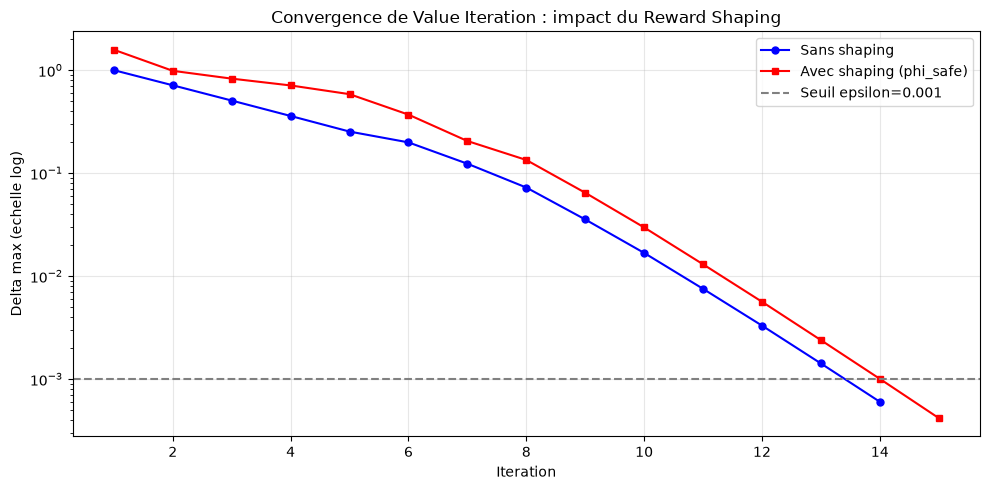


Convergence sans shaping : 14 iterations
Convergence avec shaping (phi_safe) : 15 iterations
Sur cette grille (recompense de vie -0.04 partout), le shaping n'accelere pas
la convergence : ce critere d'arret absolu compare des echelles de valeurs differentes.
La mesure tutorielle exige donc un budget commun sous recompense originale.


In [11]:
# Visualisation de l'impact du Reward Shaping sur la convergence VI
def value_iteration_shaped(mdp: GridMDP, goal, phi_func, epsilon=0.001, max_iter=100):
    """Value Iteration avec reward shaping (Ng et al., 1999).

    F(s, a, s') = gamma*Phi(s') - Phi(s) est ajoute a la recompense SANS facteur
    gamma supplementaire (la forme exacte du theoreme) : la garantie est alors
    V_shaped(s) + Phi(s) = V(s) et la politique optimale est preservee.
    Retourne V, la politique, la trace des deltas et le nombre d'iterations.
    """
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    deltas = []

    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)

        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
            else:
                q_values = []
                for a in mdp.ACTIONS:
                    q = mdp.get_reward(s)
                    for next_s, prob in mdp.get_transitions(s, a):
                        F = mdp.gamma * phi_func(next_s, goal) - phi_func(s, goal)
                        q += prob * F + mdp.gamma * prob * V[next_s]
                    q_values.append(q)
                new_V[s] = max(q_values)
            delta = max(delta, abs(V[s] - new_V[s]))

        V = new_V
        deltas.append(delta)
        if delta < epsilon:
            break

    policy = {}
    for s in states:
        if s in mdp.terminal_states:
            policy[s] = 'T'
            continue
        q_values = {}
        for a in mdp.ACTIONS:
            q = mdp.get_reward(s)
            for next_s, prob in mdp.get_transitions(s, a):
                F = mdp.gamma * phi_func(next_s, goal) - phi_func(s, goal)
                q += prob * F + mdp.gamma * prob * V[next_s]
            q_values[a] = q
        policy[s] = max(q_values, key=q_values.get)

    return V, policy, deltas, len(deltas)


# Potentiel coherent avec les terminaux : leurs valeurs sont epinglees a R(s)
# (pas d'equation de Bellman sur eux), donc le potentiel doit y etre NUL --
# sinon la telescoping du theoreme se casse a la frontiere et la politique bascule.
def phi_safe(state, goal_):
    if state in mdp.terminal_states:
        return 0.0
    return phi(state, goal_)


V_plain, policy_plain, _ = value_iteration(mdp)

# Cas 1 -- controle negatif : potentiel brut, non nul au piege (3,1) ou Phi = -1.
V_unshaped, policy_unshaped, _, _ = value_iteration_shaped(mdp, goal, phi)
flips = [s for s in mdp.get_states()
         if s not in mdp.terminal_states and policy_unshaped[s] != policy_plain[s]]
print("Controle negatif -- potentiel brut (Phi(piege) = -1.0, non nul au terminal) :")
print(f"  etats ou la politique bascule : {flips if flips else 'aucun'}")

# Cas 2 -- potentiel annule aux terminaux : la garantie s'applique et se mesure.
V_shaped, policy_shaped, deltas_shaped, iters_shaped = value_iteration_shaped(mdp, goal, phi_safe)
same_policy = all(policy_shaped[s] == policy_plain[s] for s in mdp.get_states()
                  if s not in mdp.terminal_states)
invariant = max(abs(V_shaped[s] + phi_safe(s, goal) - V_plain[s])
                for s in mdp.get_states() if s not in mdp.terminal_states)
print("\nPotentiel annule aux terminaux (phi_safe) :")
print(f"  politique identique a l'originale sur tous les etats non terminaux : {same_policy}")
print(f"  invariant V_shaped(s) + Phi(s) = V(s) : ecart max = {invariant:.2e}")

# Trace des deltas sans shaping, derivee de la trace de value_iteration_trace
history = value_iteration_trace(mdp)
deltas_plain = [max(abs(h1[s] - h0[s]) for s in mdp.get_states())
                for h0, h1 in zip(history, history[1:])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(range(1, len(deltas_plain)+1), deltas_plain, 'b-o', label='Sans shaping', markersize=5)
ax.semilogy(range(1, len(deltas_shaped)+1), deltas_shaped, 'r-s', label='Avec shaping (phi_safe)', markersize=5)
ax.axhline(y=0.001, color='gray', linestyle='--', label='Seuil epsilon=0.001')
ax.set_xlabel('Iteration')
ax.set_ylabel('Delta max (echelle log)')
ax.set_title('Convergence de Value Iteration : impact du Reward Shaping')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_shaping_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nConvergence sans shaping : {len(deltas_plain)} iterations")
print(f"Convergence avec shaping (phi_safe) : {iters_shaped} iterations")
print("Sur cette grille (recompense de vie -0.04 partout), le shaping n'accelere pas")
print("la convergence : ce critere d'arret absolu compare des echelles de valeurs differentes.")
print("La mesure tutorielle exige donc un budget commun sous recompense originale.")


### Interprétation : correction mathématique et limite du critère epsilon

Sur la grille 4×3, le contrôle négatif montre qu’un potentiel non nul au terminal défavorable peut changer la politique avec la convention terminale du notebook. En annulant le potentiel sur **tous** les terminaux, la politique finale est préservée et l’invariant $V_{shaped}(s)+\Phi(s)=V(s)$ est retrouvé à la tolérance de convergence.

En revanche, les 15 itérations shaped ne battent pas les 14 itérations plain. Ce résultat interdit d’utiliser ici le nombre de sweeps jusqu’à un epsilon absolu comme preuve d’accélération : le shaping change l’échelle des valeurs et la trajectoire du résidu.

### Mesurer le rôle tutoriel à profondeur finie

Nous comparons maintenant les deux méthodes avec **le même budget de cinq sweeps synchrones** sur un corridor sparse stochastique de 12 états. Après chaque sweep, la politique gloutonne est évaluée exactement sous la **récompense originale non shaped**. Les critères sont le retour au départ, le regret face à la politique optimale finale, la fraction d’actions identiques à cette politique et le premier sweep où l’action optimale apparaît au départ.

Les probabilités de transition sont sommées exactement : aucun échantillonnage ni seed n’intervient.


Convergence apres 38 iterations (delta = 2.97e-13)
=== Expérience à profondeur finie : corridor sparse stochastique ===
États : 12 | distance départ-but : 11
Budget identique : 5 sweeps synchrones par méthode
Action optimale au départ : E

Sweep | action plain/shaped | retour plain/shaped | accord plain/shaped
    1 |     N/E      | 0.00005/0.23917 | 9%/100%
    2 |     N/E      | 0.00012/0.23917 | 18%/100%
    3 |     N/E      | 0.00028/0.23917 | 27%/100%
    5 |     N/E      | 0.00166/0.23917 | 45%/100%
    8 |     N/E      | 0.02323/0.23917 | 73%/100%
   10 |     N/E      | 0.12903/0.23917 | 91%/100%
   11 |     E/E      | 0.23917/0.23917 | 100%/100%
   12 |     E/E      | 0.23917/0.23917 | 100%/100%

CLAIM_METRICS {"final_policy_equal": true, "finite_budget_sweeps": 5, "finite_depth_tutoring_supported": true, "first_optimal_sweep_plain": 11, "first_optimal_sweep_shaped": 1, "policy_match_at_budget_plain": 0.45454545, "policy_match_at_budget_shaped": 1.0, "regret_at_budget_plain": 0

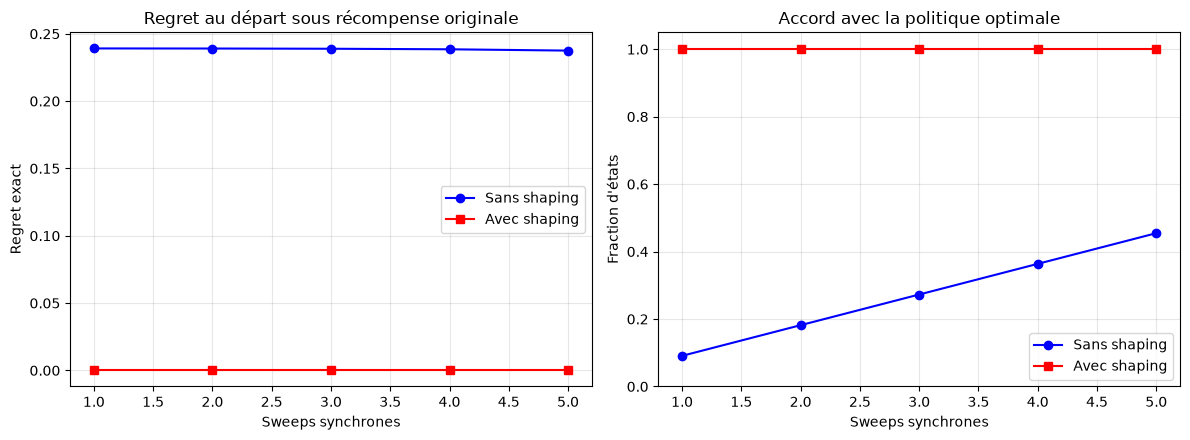

In [12]:
# Expérience discriminante à profondeur finie et budget de backups égal
import json


def greedy_policy_from_values(mdp, values, goal=None, phi_func=None):
    """Extrait une politique avec le même ordre d'actions pour les deux méthodes."""
    policy = {}
    for state in mdp.get_states():
        if state in mdp.terminal_states:
            policy[state] = "T"
            continue
        q_values = {}
        for action in mdp.ACTIONS:
            q_value = mdp.get_reward(state)
            for next_state, probability in mdp.get_transitions(state, action):
                if phi_func is not None:
                    shaping = (
                        mdp.gamma * phi_func(next_state, goal)
                        - phi_func(state, goal)
                    )
                    q_value += probability * shaping
                q_value += mdp.gamma * probability * values[next_state]
            q_values[action] = q_value
        policy[state] = max(q_values, key=q_values.get)
    return policy


def finite_depth_traces(mdp, sweeps, goal=None, phi_func=None):
    """Enregistre valeurs et politique après chaque sweep synchrone."""
    states = mdp.get_states()
    values = {state: 0.0 for state in states}
    traces = []
    for _ in range(sweeps):
        new_values = dict(values)
        for state in states:
            if state in mdp.terminal_states:
                new_values[state] = mdp.get_reward(state)
                continue
            candidates = []
            for action in mdp.ACTIONS:
                q_value = mdp.get_reward(state)
                for next_state, probability in mdp.get_transitions(state, action):
                    if phi_func is not None:
                        shaping = (
                            mdp.gamma * phi_func(next_state, goal)
                            - phi_func(state, goal)
                        )
                        q_value += probability * shaping
                    q_value += mdp.gamma * probability * values[next_state]
                candidates.append(q_value)
            new_values[state] = max(candidates)
        values = new_values
        policy = greedy_policy_from_values(mdp, values, goal, phi_func)
        traces.append((dict(values), policy))
    return traces


def evaluate_policy_exactly(mdp, policy):
    """Évalue une politique sous la récompense originale par système linéaire."""
    non_terminal = [
        state for state in mdp.get_states()
        if state not in mdp.terminal_states
    ]
    index = {state: position for position, state in enumerate(non_terminal)}
    matrix = np.eye(len(non_terminal))
    target = np.array(
        [mdp.get_reward(state) for state in non_terminal],
        dtype=float,
    )
    for state in non_terminal:
        row = index[state]
        for next_state, probability in mdp.get_transitions(state, policy[state]):
            if next_state in index:
                matrix[row, index[next_state]] -= mdp.gamma * probability
            else:
                target[row] += (
                    mdp.gamma * probability * mdp.get_reward(next_state)
                )
    solution = np.linalg.solve(matrix, target)
    return {
        **{state: solution[index[state]] for state in non_terminal},
        **{
            state: mdp.get_reward(state)
            for state in mdp.terminal_states
        },
    }


corridor_depth = 12
finite_budget = 5
max_sweeps = 30
deep_mdp = GridMDP(corridor_depth, 1, gamma=0.9)
deep_mdp.rewards = {state: 0.0 for state in deep_mdp.get_states()}
deep_goal = (corridor_depth - 1, 0)
deep_start = (0, 0)
deep_mdp.rewards[deep_goal] = 1.0
deep_mdp.terminal_states = {deep_goal}


def deep_phi_safe(state, goal):
    """Distance signée au but, nulle sur le terminal épinglé."""
    if state in deep_mdp.terminal_states:
        return 0.0
    return -float(goal[0] - state[0])


plain_traces = finite_depth_traces(deep_mdp, max_sweeps)
shaped_traces = finite_depth_traces(
    deep_mdp, max_sweeps, deep_goal, deep_phi_safe
)
_, optimal_policy, _ = value_iteration(deep_mdp, epsilon=1e-12, max_iter=500)
optimal_return = evaluate_policy_exactly(deep_mdp, optimal_policy)[deep_start]
non_terminal = [
    state for state in deep_mdp.get_states()
    if state not in deep_mdp.terminal_states
]


def progress_rows(traces):
    rows = []
    for sweep, (_, policy) in enumerate(traces, start=1):
        start_return = evaluate_policy_exactly(deep_mdp, policy)[deep_start]
        policy_match = sum(
            policy[state] == optimal_policy[state]
            for state in non_terminal
        ) / len(non_terminal)
        rows.append({
            "sweep": sweep,
            "start_action": policy[deep_start],
            "return": start_return,
            "regret": max(0.0, optimal_return - start_return),
            "policy_match": policy_match,
        })
    return rows


plain_progress = progress_rows(plain_traces)
shaped_progress = progress_rows(shaped_traces)
optimal_start_action = optimal_policy[deep_start]
first_optimal_sweep_plain = next(
    row["sweep"] for row in plain_progress
    if row["start_action"] == optimal_start_action
)
first_optimal_sweep_shaped = next(
    row["sweep"] for row in shaped_progress
    if row["start_action"] == optimal_start_action
)
plain_budget = plain_progress[finite_budget - 1]
shaped_budget = shaped_progress[finite_budget - 1]
regret_auc_plain = sum(
    row["regret"] for row in plain_progress[:finite_budget]
)
regret_auc_shaped = sum(
    row["regret"] for row in shaped_progress[:finite_budget]
)
final_policy_equal = all(
    plain_traces[-1][1][state] == optimal_policy[state]
    and shaped_traces[-1][1][state] == optimal_policy[state]
    for state in non_terminal
)
earlier_guidance = first_optimal_sweep_shaped < first_optimal_sweep_plain
lower_cumulative_regret = regret_auc_shaped < regret_auc_plain
if not final_policy_equal:
    tutoring_verdict = "CONTRADICTED"
elif earlier_guidance and lower_cumulative_regret:
    tutoring_verdict = "SUPPORTED"
else:
    tutoring_verdict = "UNPROVEN"

print("=== Expérience à profondeur finie : corridor sparse stochastique ===")
print(f"États : {corridor_depth} | distance départ-but : {corridor_depth - 1}")
print(f"Budget identique : {finite_budget} sweeps synchrones par méthode")
print(f"Action optimale au départ : {optimal_start_action}")
print("\nSweep | action plain/shaped | retour plain/shaped | accord plain/shaped")
for sweep in (1, 2, 3, finite_budget, 8, 10, 11, 12):
    plain_row = plain_progress[sweep - 1]
    shaped_row = shaped_progress[sweep - 1]
    print(
        f"{sweep:>5} | {plain_row['start_action']:>5}/{shaped_row['start_action']:<6}"
        f" | {plain_row['return']:.5f}/{shaped_row['return']:.5f}"
        f" | {plain_row['policy_match']:.0%}/{shaped_row['policy_match']:.0%}"
    )

metrics = {
    "finite_budget_sweeps": finite_budget,
    "first_optimal_sweep_plain": first_optimal_sweep_plain,
    "first_optimal_sweep_shaped": first_optimal_sweep_shaped,
    "return_at_budget_plain": round(plain_budget["return"], 8),
    "return_at_budget_shaped": round(shaped_budget["return"], 8),
    "regret_at_budget_plain": round(plain_budget["regret"], 8),
    "regret_at_budget_shaped": round(shaped_budget["regret"], 8),
    "policy_match_at_budget_plain": round(plain_budget["policy_match"], 8),
    "policy_match_at_budget_shaped": round(shaped_budget["policy_match"], 8),
    "regret_auc_plain": round(regret_auc_plain, 8),
    "regret_auc_shaped": round(regret_auc_shaped, 8),
    "final_policy_equal": final_policy_equal,
    "finite_depth_tutoring_supported": tutoring_verdict == "SUPPORTED",
}
print("\nCLAIM_METRICS " + json.dumps(metrics, sort_keys=True))
print(f"Verdict tutoriel à profondeur finie : {tutoring_verdict}")

sweeps = np.arange(1, finite_budget + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    sweeps,
    [row["regret"] for row in plain_progress[:finite_budget]],
    "b-o",
    label="Sans shaping",
)
axes[0].plot(
    sweeps,
    [row["regret"] for row in shaped_progress[:finite_budget]],
    "r-s",
    label="Avec shaping",
)
axes[0].set_title("Regret au départ sous récompense originale")
axes[0].set_xlabel("Sweeps synchrones")
axes[0].set_ylabel("Regret exact")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(
    sweeps,
    [row["policy_match"] for row in plain_progress[:finite_budget]],
    "b-o",
    label="Sans shaping",
)
axes[1].plot(
    sweeps,
    [row["policy_match"] for row in shaped_progress[:finite_budget]],
    "r-s",
    label="Avec shaping",
)
axes[1].set_title("Accord avec la politique optimale")
axes[1].set_xlabel("Sweeps synchrones")
axes[1].set_ylabel("Fraction d'états")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.savefig("reward_shaping_finite_depth.png", dpi=100, bbox_inches="tight")
plt.show()


### Lecture du résultat à budget égal

<!-- claim-check: {"id":"shaping-earlier-start-action","left":"first_optimal_sweep_shaped","op":"<","right":"first_optimal_sweep_plain"} -->
<!-- claim-check: {"id":"shaping-lower-cumulative-regret","left":"regret_auc_shaped","op":"<","right":"regret_auc_plain"} -->
<!-- claim-check: {"id":"shaping-better-return-at-budget","left":"return_at_budget_shaped","op":">","right":"return_at_budget_plain"} -->
<!-- claim-check: {"id":"shaping-final-policy-preserved","left":"final_policy_equal","op":"==","right":true} -->
<!-- claim-check: {"id":"shaping-finite-depth-verdict","left":"finite_depth_tutoring_supported","op":"==","right":true} -->

Sous le budget commun de cinq sweeps, le shaping atteint l’action optimale au départ au sweep **1**, contre **11** sans shaping. Son retour exact sous la récompense originale vaut déjà **0,23917**, contre **0,00166**, et sa politique coïncide avec l’optimum sur tous les états non terminaux dès le premier sweep. L’aire de regret sur les cinq sweeps est donc strictement plus faible.

Le verdict calculé est `SUPPORTED` pour ce rôle tutoriel **sur ce problème borné** : le potentiel transmet immédiatement une direction utile alors que la récompense terminale met onze sweeps à atteindre le départ sans shaping. Les politiques finales plain et shaped coïncident avec la politique optimale, ce qui sépare bien l’aide à profondeur finie de la préservation asymptotique.

Cette observation n’établit pas que le reward shaping réduit universellement le nombre d’itérations jusqu’à convergence. Le contrôle 4×3 précédent mesure précisément le contraire pour l’epsilon choisi. La conclusion soutenue est locale et falsifiable : à budget de backups égal, sur ce corridor sparse, le shaping sûr fournit plus tôt une politique utile sans changer l’optimum final.


***

### Synthese : Comparaison des méthodes de résolution MDP

| Méthode | Complexite/iter | Nb itérations | Avantage |
|---------|-----------------|---------------|----------|
| **Value Itération** | $O(\vert S\vert^2 \vert A\vert)$ | 14 (grille 4×3) | Simple, garantit convergence |
| **Policy Itération** | $O(\vert S\vert^3 + \vert S\vert^2\vert A\vert)$ | 3 (grille 4×3) | Moins de sweeps, mais chaque sweep plus coûteux |
| **RTDP** | $O(\text{traj})$ | Variable | Echantillonne, pas besoin de tout explorer |

## 8. Bandits Multi-Bras

### Le problème

Vous avez K machines a sous ("bras"). Chaque bras $i$ donne une recompense selon une distribution inconnue.

**Dilemme exploration-exploitation** :
- **Exploiter** : Tirer le bras qui semble meilleur
- **Explorer** : Tester d'autrès bras pour mieux estimer leurs moyennes

In [13]:
class MultiArmedBandit:
    """Bandit multi-bras avec recompenses gaussiennes."""
    
    def __init__(self, means, seed=42):
        self.true_means = np.array(means)
        self.K = len(means)
        self.rng = np.random.RandomState(seed)
    
    def pull(self, arm):
        return self.true_means[arm] + 0.5 * self.rng.randn()
    
    @property
    def optimal_mean(self):
        return self.true_means.max()


class EpsilonGreedy:
    """Strategie epsilon-greedy."""
    
    def __init__(self, epsilon, seed=42):
        self.epsilon = epsilon
        self.name = f"epsilon-greedy (e={epsilon})"
        self.rng = np.random.RandomState(seed)
    
    def select_arm(self, counts, sum_rewards):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(len(counts))
        means = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0)
        return np.argmax(means)


class UCB1:
    """Strategie Upper Confidence Bound."""
    
    @property
    def name(self):
        return "UCB1"
    
    def select_arm(self, counts, sum_rewards):
        total = counts.sum()
        if total < len(counts):
            return int(total)
        means = sum_rewards / counts
        bonus = np.sqrt(2 * np.log(total) / counts)
        return np.argmax(means + bonus)


def run_bandit(bandit, strategy, T=1000):
    counts = np.zeros(bandit.K, dtype=int)
    sum_rewards = np.zeros(bandit.K)
    total_reward = 0
    total_regret = 0
    
    for t in range(T):
        arm = strategy.select_arm(counts, sum_rewards)
        reward = bandit.pull(arm)
        counts[arm] += 1
        sum_rewards[arm] += reward
        total_reward += reward
        total_regret += bandit.optimal_mean - reward
    
    return total_reward, total_regret, counts


bandit = MultiArmedBandit([0.3, 0.5, 0.7, 0.4])
strategies = [EpsilonGreedy(0.1), UCB1()]

print(f"Bandit avec {bandit.K} bras, moyennes vraies inconnues")
print(f"Meilleure moyenne : {bandit.optimal_mean}\n")

for strategy in strategies:
    total_r, total_reg, counts = run_bandit(bandit, strategy)
    print(f"{strategy.name}:")
    print(f"  Recompense totale : {total_r:.1f}")
    print(f"  Regret cumule : {total_reg:.1f}")
    print(f"  Tirages par bras : {list(counts)}\n")

Bandit avec 4 bras, moyennes vraies inconnues
Meilleure moyenne : 0.7

epsilon-greedy (e=0.1):
  Recompense totale : 677.6
  Regret cumule : 22.4
  Tirages par bras : [np.int64(46), np.int64(22), np.int64(901), np.int64(31)]

UCB1:
  Recompense totale : 666.5
  Regret cumule : 33.5
  Tirages par bras : [np.int64(50), np.int64(174), np.int64(729), np.int64(47)]



***

## Exercice : Thompson Sampling vs Epsilon-Greedy sur 5 Bras

**Objectifs** :
1. Implementer une stratégie Thompson Sampling pour un bandit a 5 bras
2. Tracer les courbes de regret cumule et comparer avec epsilon-greedy
3. Observer comment Thompson Sampling équilibre exploration et exploitation

**Contexte** : Un bandit a 5 bras avec des moyennes inconnues `[0.2, 0.4, 0.6, 0.8, 0.5]`. Le bras optimal est le bras 3 (moyenne 0.8). Vous devez implementer Thompson Sampling en utilisant des posteriors Beta (approche analytique), puis comparer avec epsilon-greedy sur 1000 pas de temps.

**Indices** :
- Utiliser la classe `MultiArmedBandit` définie plus haut pour simuler les tirages
- Pour Thompson Sampling : maintenir des parametrès `alpha_i` et `beta_i` pour chaque bras, initialises a 1.0
- A chaque pas : echantillonner `theta_i ~ Beta(alpha_i, beta_i)` pour chaque bras, choisir `argmax(theta_i)`
- Après le tirage : si `reward > seuil`, incrementer `alpha_i`, sinon incrementer `beta_i`
- Utiliser `run_bandit_tracking` pour collecter les regrets, puis tracer avec `plt.plot`

In [14]:
# Exercice : Thompson Sampling vs Epsilon-Greedy sur 5 Bras

# Etape 1 : Definir les vraies moyennes des 5 bras et creer le bandit
true_means_5 = [0.2, 0.4, 0.6, 0.8, 0.5]
K = len(true_means_5)

# TODO etudiant : creer le bandit avec MultiArmedBandit
bandit_5 = None  # TODO etudiant : utiliser MultiArmedBandit(true_means_5)

# Etape 2 : Implementer Thompson Sampling manuellement
# TODO etudiant : initialiser alpha_i = beta_i = 1.0 pour chaque bras
alphas = None  # TODO etudiant : np.ones(K)
betas = None   # TODO etudiant : np.ones(K)

# Etape 3 : Boucle de 1000 pas
T = 1000
# TODO etudiant : implementer la boucle Thompson Sampling
#   - Echantillonner theta_i ~ Beta(alphas[i], betas[i]) pour chaque bras
#   - Choisir argmax(theta_i)
#   - Tirer le bras choisi avec bandit_5.pull(arm)
#   - Mettre a jour alphas/betas selon le resultat
#   - Enregistrer le regret cumule

# Etape 4 : Comparer avec epsilon-greedy (utiliser run_bandit_tracking)
# TODO etudiant : executer EpsilonGreedy(0.1) sur le meme bandit

# Etape 5 : Tracer les courbes de regret cumule
# TODO etudiant : plt.plot(regret_ts, label='Thompson Sampling')
# TODO etudiant : plt.plot(regret_eg, label='Epsilon-Greedy')
# TODO etudiant : ajouter labels, legend, titre

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : implementez Thompson Sampling et comparez avec epsilon-greedy")

Exercice a completer : implementez Thompson Sampling et comparez avec epsilon-greedy


### Interpretation des stratégies de bandits

**Moyennes vraies (inconnues de l'agent) :** Bras 1=0.3, Bras 2=0.5, **Bras 3=0.7**, Bras 4=0.4

**Comparaison :**
- **$\varepsilon$-greedy** : avec $\varepsilon=0.1$, exploite fortement le meilleur bras identifie
- **UCB1** : explore plus systématiquement au debut, puis exploite

**Regret** : le regret cumule mesure la perte par rapport a l'oracle (qui connait le meilleur bras). Plus il est faible, meilleure est la stratégie.

### Le cadre SFABP et la preuve d'optimalite

L'indice de Gittins repose sur le cadre formel des **SFABP** (Simple Family of Alternative Bandit Processes) :

**Definition** : Un SFABP est un ensemble de $K$ processus stochastiques independants (les "bras"). A chaque instant, l'agent active exactement un processus ; les autrès sont geles. L'objectif est de maximiser la somme escomptee des recompenses.

**L'argument des "prevailing charges"** (preuve constructive, Whittle 1982) :
1. Pour chaque bras $i$, définir une "charge" $\lambda_i$ (seuil d'indifference)
2. L'indice de Gittins $\nu_i(t)$ est la plus grande charge $\lambda$ telle que l'agent est indifferent entre activer le bras $i$ ou recevoir $\lambda$ a chaque pas futur
3. La politique optimale consiste a activer le bras avec le plus haut indice

$$\nu_i(t) = \sup \left\{ \lambda : \mathbb{E}\left[\sum_{\tau=0}^{\infty} \gamma^\tau R_i(t+\tau) \mid \text{continuer sur } i\right] \geq \mathbb{E}\left[\sum_{\tau=0}^{\infty} \gamma^\tau \lambda\right] \right\}$$

**Limites importantes** :
- Le résultat d'optimalite de Gittins s'applique **uniquement** au cas a recompenses escomptees (geometric discount)
- Le calcul exact est **NP-difficile** dans le cas général
- Pour le cas a horizon fini ou adversarial, d'autrès stratégies (UCB, Exp3) sont préférables

## 9. Indice de Gittins

### Le Theoreme Fondamental (Gittins, 1979)

L'indice de Gittins est l'un des résultats les plus elegants de la théorie des bandits : il transforme un problème dynamique en une serie de decisions statiques.

**Résultat** : Pour un bandit stochastique avec recompenses escomptees, il existe un indice $\nu_i(t)$ pour chaque bras $i$ au temps $t$ tel que la politique optimale est simplement :

$$a_t = \arg\max_i \nu_i(t)$$

### Calcul pratique et approximation UCB1 (Auer et al., 2002)

Le calcul exact de l'indice de Gittins est NP-difficile dans le cas général. Heureusement, **UCB1 fournit une approximation asymptotiquement optimale** :

| Aspect | Gittins (exact) | UCB1 (approximation) |
|--------|-----------------|----------------------|
| Formule | Programmation dynamique sur l'horizon | $\hat{\mu}_i + \sqrt{2\ln t / n_i}$ |
| Complexite | Exponentielle en l'horizon | $O(1)$ par bras |
| Optimalite | Exacte (geometric discount) | Asymptotiquement optimale |
| Applicabilite | Recompenses escomptees | Recompenses cumulees |

**Règle pratique** : UCB1 est l'approximation standard de l'indice de Gittins pour les bandits stochastiques a horizon fini. La demonstration ci-dessous compare empiriquement les deux approches.

### Trois formulations du problème de bandits

La théorie des bandits distingue trois natures de sequences de recompenses, chacune correspondant a une famille d'algorithmes optimale :

| Formulation | Nature des recompenses | Stratégie optimale | Principe |
|-------------|----------------------|---------------------|----------|
| **Stochastique** | Distribution inconnue, i.i.d. | **UCB** (Upper Confidence Bound) | Optimisme face a l'incertitude |
| **Adversariale** | Choisis par un adversaire | **Hedge / Exp3** | Distribution de probabilités sur les bras |
| **Markovienne** | Transitions d'etat connues | **Indice de Gittins** | Index indépendant par bras, optimal sous discount |

> **Cette section** se concentre sur la formulation Markovienne et l'indice de Gittins. Pour une discussion approfondie du cadre SFABP (Famille Simple de Processus Bandits Alternatifs) et de la preuve constructive d'optimalite (argument des "prevailing charges"), voir le notebook compagnon [Infer-8](../DecInfer/DecInfer-08-Sequential.ipynb) qui detaille ces aspects théoriques.

In [15]:
# UCB1 : une politique d'indice fondee sur l'optimisme, comparee a l'indice de Gittins
# On simule un bandit 4-bras et on compare les indices UCB1 aux moyennes estimees

print("=== UCB1 : une politique d'indice fondee sur l'optimisme ===\n")

# Bandit avec 4 bras
gittins_means = [0.3, 0.5, 0.7, 0.4]
bandit_g = MultiArmedBandit(gittins_means)
K_g = len(gittins_means)

# Phase d'exploration initiale : tirer chaque bras 5 fois
counts_g = np.zeros(K_g, dtype=int)
sums_g = np.zeros(K_g)
for arm in range(K_g):
    for _ in range(5):
        r = bandit_g.pull(arm)
        counts_g[arm] += 1
        sums_g[arm] += r

print("Apres 5 tirages par bras :\n")
print(f"  {'Bras':>6} | {'Moyenne estimee':>16} | {'UCB1 (indice optimisme)':>22}")
print(f"  {'-'*6}-+-{'-'*16}-+-{'-'*22}")
for arm in range(K_g):
    mu_hat = sums_g[arm] / counts_g[arm]
    bonus = np.sqrt(2 * np.log(counts_g.sum()) / counts_g[arm])
    ucb = mu_hat + bonus
    print(f"  {arm:>6} | {mu_hat:>16.4f} | {ucb:>22.4f}")

print(f"\n  => Bras choisi par UCB1 : {np.argmax(sums_g / counts_g + np.sqrt(2 * np.log(counts_g.sum()) / counts_g))}")
print(f"  => Vrai meilleur bras : {np.argmax(gittins_means)} (moyenne = {max(gittins_means)})")

# Evolution de l'index UCB1 au fil du temps
print("\n--- Evolution de l'index UCB1 au fil des tirages ---\n")
bandit_evo = MultiArmedBandit(gittins_means)
counts_evo = np.zeros(K_g, dtype=int)
sums_evo = np.zeros(K_g)

# Phase initiale : tirer chaque bras 2 fois
for arm in range(K_g):
    for _ in range(2):
        r = bandit_evo.pull(arm)
        counts_evo[arm] += 1
        sums_evo[arm] += r

ucb1_strat = UCB1()
# Simuler 100 pas UCB1
for t in range(100):
    arm = ucb1_strat.select_arm(counts_evo, sums_evo)
    reward = bandit_evo.pull(arm)
    counts_evo[arm] += 1
    sums_evo[arm] += reward

print(f"Apres 100 pas UCB1 :\n")
print(f"  {'Bras':>6} | {'Tirages':>8} | {'Moyenne':>10} | {'UCB1 index':>12}")
print(f"  {'-'*6}-+-{'-'*8}-+-{'-'*10}-+-{'-'*12}")
for arm in range(K_g):
    mu_hat = sums_evo[arm] / counts_evo[arm]
    bonus = np.sqrt(2 * np.log(counts_evo.sum()) / counts_evo[arm])
    ucb = mu_hat + bonus
    print(f"  {arm:>6} | {counts_evo[arm]:>8} | {mu_hat:>10.4f} | {ucb:>12.4f}")

print(f"\n=> L'index UCB1 du meilleur bras ({np.argmax(gittins_means)}) est le plus eleve")
print(f"=> Les bras sous-optimaux ont un index plus faible car leur bonus d'exploration decroit")
print(f"=> Comme l'indice de Gittins, UCB1 est une politique d'INDICE : un score independant par bras")
print(f"=> Mais ce score est un bonus d'optimisme frequentiste, pas l'indice bayesien de Gittins :")
print(f"   ni prior, ni facteur d'actualisation (cf. tableau comparatif et cadre SFABP ci-dessus)")

=== UCB1 : une politique d'indice fondee sur l'optimisme ===

Apres 5 tirages par bras :

    Bras |  Moyenne estimee | UCB1 (indice optimisme)
  -------+------------------+-----------------------
       0 |           0.5295 |                 1.6242
       1 |           0.7186 |                 1.8132
       2 |           0.2675 |                 1.3621
       3 |           0.0419 |                 1.1365

  => Bras choisi par UCB1 : 1
  => Vrai meilleur bras : 2 (moyenne = 0.7)

--- Evolution de l'index UCB1 au fil des tirages ---

Apres 100 pas UCB1 :

    Bras |  Tirages |    Moyenne |   UCB1 index
  -------+----------+------------+-------------
       0 |       12 |     0.1489 |       1.0322
       1 |       37 |     0.5482 |       1.0513
       2 |       40 |     0.5926 |       1.0765
       3 |       19 |     0.3364 |       1.0385

=> L'index UCB1 du meilleur bras (2) est le plus eleve
=> Les bras sous-optimaux ont un index plus faible car leur bonus d'exploration decroit
=> Comm

### Interpretation : Indice de Gittins et politique d'indice UCB1

**Deux politiques d'indice, deux objectifs :**

L'indice UCB1 $\hat{\mu}_i + \sqrt{2\ln t / n_i}$ est, comme l'indice de Gittins, une **politique d'indice** : chaque bras porte un score independant, et on choisit le meilleur score. Mais les deux scores ne mesurent pas la meme chose :

- **Gittins** : indice bayesien exact -- suppose un prior et un facteur d'actualisation geometrique, optimal pour les recompenses *escomptees*, NP-difficile a calculer en general
- **UCB1** : bonus d'optimisme frequentiste -- aucun prior, aucun facteur d'actualisation, asymptotiquement optimal pour les recompenses *cumulees*, calculable en $O(1)$ par bras

**Observations empiriques :**

| Propriete | Observation |
|-----------|------------|
| **Convergence** | Le meilleur bras obtient le plus d'allocations au fil du temps |
| **Exploration decroissante** | Le bonus $\sqrt{2\ln t / n_i}$ diminue pour les bras souvent tires |
| **Index independants** | Chaque bras a un score propre, sans reference aux autres bras |

**Ce que la demonstration compare** : le mecanisme exploration/exploitation commun aux politiques d'indice. Elle ne calcule pas l'indice de Gittins -- cela exigerait un prior et un facteur d'actualisation (cf. le cadre SFABP et le tableau comparatif ci-dessus).


## 10. POMDPs : MDPs Partiellement Observables

### Motivation

Dans un MDP standard, l'agent connait l'etat exact du monde. En pratique, les capteurs sont **imparfaits** : l'agent n'observe qu'une partie de l'etat.

Un POMDP ajoute :
- Un ensemble d'**observations** $O$
- Une probabilité d'observation $P(o|s',a)$

L'agent maintient un **belief state** $b(s) = P(s|\text{historique})$ (Smallwood & Sondik, 1973) et met a jour ce belief via le **theoreme de Bayes**.

In [16]:
print("=== POMDP : Probleme du Tigre ===\n")
print("Deux portes : gauche (G) et droite (D)")
print("Un tigre est cache derriere l'une des portes.")
print("Actions : Ouvrir G, Ouvrir D, Ecouter\n")

p_correct = 0.85  # P(bruit_gauche | tigre_gauche)
reward_treasure = 10
reward_tiger = -100
cost_listen = -1

# Belief state : b = P(tigre_gauche)
b = 0.5

def eu_open_left(belief):
    return belief * reward_tiger + (1 - belief) * reward_treasure

def eu_open_right(belief):
    return belief * reward_treasure + (1 - belief) * reward_tiger

print(f"Belief initial : P(tigre gauche) = {b:.0%}\n")

print("Utilites esperees :")
print(f"  E[U(ouvrir gauche) | b={b:.0%}] = {eu_open_left(b):.1f}")
print(f"  E[U(ouvrir droite) | b={b:.0%}] = {eu_open_right(b):.1f}")
print(f"  Ecouter : cout immediat = {cost_listen}, mais reduit l'incertitude\n")

print("Simulation : 3 ecoutes donnent 'bruit gauche'\n")

for i in range(3):
    # Mise a jour bayesienne
    p_noise_left = b * p_correct + (1 - b) * (1 - p_correct)
    b = (p_correct * b) / p_noise_left
    print(f"Apres observation {i+1} : P(tigre gauche) = {b:.1%}")

print()
print(f"E[U(ouvrir gauche)] = {eu_open_left(b):.1f}")
print(f"E[U(ouvrir droite)] = {eu_open_right(b):.1f}")
print()
print(f"=> Decision : OUVRIR DROITE (tigre probablement a gauche)")

=== POMDP : Probleme du Tigre ===

Deux portes : gauche (G) et droite (D)
Un tigre est cache derriere l'une des portes.
Actions : Ouvrir G, Ouvrir D, Ecouter

Belief initial : P(tigre gauche) = 50%

Utilites esperees :
  E[U(ouvrir gauche) | b=50%] = -45.0
  E[U(ouvrir droite) | b=50%] = -45.0
  Ecouter : cout immediat = -1, mais reduit l'incertitude

Simulation : 3 ecoutes donnent 'bruit gauche'

Apres observation 1 : P(tigre gauche) = 85.0%
Apres observation 2 : P(tigre gauche) = 97.0%
Apres observation 3 : P(tigre gauche) = 99.5%

E[U(ouvrir gauche)] = -99.4
E[U(ouvrir droite)] = 9.4

=> Decision : OUVRIR DROITE (tigre probablement a gauche)


### Interpretation du problème du tigre (POMDP)

**Evolution du belief state :**

| Étape | P(tigre gauche) | Decision optimale |
|-------|-----------------|-------------------|
| 0 | 50% | Ecouter (trop incertain) |
| 1 | 85% | Ecouter |
| 2 | 97% | Ecouter ou ouvrir droite |
| 3 | 99.5% | Ouvrir droite |

**Principe cle** : l'information a une valeur. Payer -1 pour ecouter est rationnel quand l'incertitude est elevee, car une mauvaise decision coute -100.

## 10bis. Belief State Updates : Maintenance Predictive

Le problème du tigre calculait les mises a jour "a la main". Verifions le même principe avec un **modèle de maintenance predictive** plus complet, utilisant les opérations matricielles numpy.

### Scénario
Un système industriel peut etre dans 3 etats : **Bon**, **Degrade**, **Defaillant**. Des capteurs de vibration fournissent des observations bruitees. On met a jour le belief state par prediction-correction (filtre bayesien).

=== Belief State Updates : Maintenance Predictive ===

Belief initial :
  P(Bon) = 95.0%
  P(Degrade) = 4.0%
  P(Defaillant) = 1.0%

=== Pas de temps 1 ===
Apres prediction (transition) :
  P(Bon) = 85.5%
  P(Degrade) = 11.0%
  P(Defaillant) = 3.5%
Observation : Normal
Apres correction (Bayes) :
  P(Bon       ) = 95.9%
  P(Degrade   ) = 3.9%
  P(Defaillant) = 0.2%
Utilites esperees :
  E[U(Continuer   )] =    96.8
  E[U(Maintenance )] =   -16.2
  E[U(Remplacer   )] =   -99.7
=> Decision : Continuer

=== Pas de temps 2 ===
Apres prediction (transition) :
  P(Bon) = 86.3%
  P(Degrade) = 11.0%
  P(Defaillant) = 2.7%
Observation : Anormal
Apres correction (Bayes) :
  P(Bon       ) = 29.6%
  P(Degrade   ) = 52.7%
  P(Defaillant) = 17.7%
Utilites esperees :
  E[U(Continuer   )] =   -32.3
  E[U(Maintenance )] =    27.4
  E[U(Remplacer   )] =   -73.5
=> Decision : Maintenance

=== Pas de temps 3 ===
Apres prediction (transition) :
  P(Bon) = 26.6%
  P(Degrade) = 47.2%
  P(Defaillant) = 26.2%
O

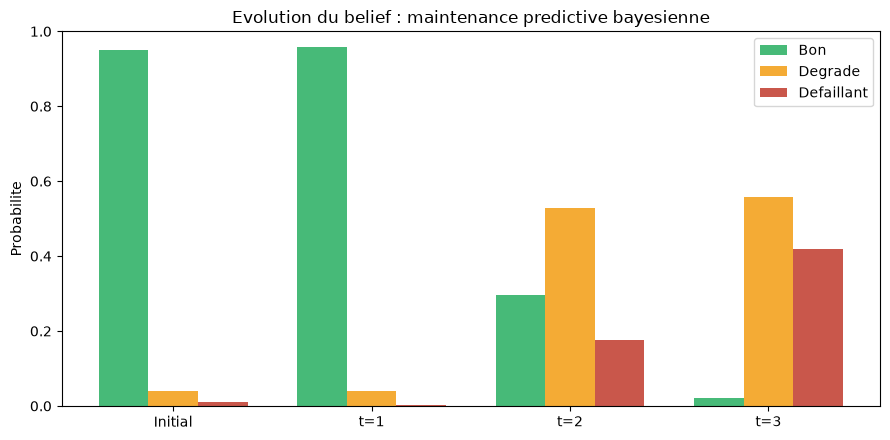

=== Resume ===
Les observations 'Anormal' successives ont fait augmenter P(Degrade),
declenchant le passage de 'Continuer' a 'Maintenance'.

C'est le principe de la maintenance predictive bayesienne !


In [17]:
# Matrice de transition (degradation naturelle)
trans_matrix = np.array([
    [0.90, 0.08, 0.02],   # Bon -> Bon, Degrade, Defaillant
    [0.00, 0.85, 0.15],   # Degrade -> Degrade, Defaillant
    [0.00, 0.00, 1.00],   # Defaillant (absorbant)
])

# Modele d'observation : P(obs | etat)
obs_matrix = np.array([
    [0.95, 0.05],   # Bon -> Normal, Anormal
    [0.30, 0.70],   # Degrade -> Normal, Anormal
    [0.05, 0.95],   # Defaillant -> Normal, Anormal
])

# Utilites des decisions
utilities = np.array([
    [ 100,   50, -500],   # Continuer
    [ -20,   80,  -50],   # Maintenance
    [-100, -100,   50],   # Remplacer
])
actions_nom = ["Continuer", "Maintenance", "Remplacer"]
etats_nom = ["Bon", "Degrade", "Defaillant"]

# Observations sequentielles : Normal, Anormal, Anormal
observations = [0, 1, 1]
obs_labels = ["Normal", "Anormal"]

# Belief initial (systeme venant d'etre installe)
belief = np.array([0.95, 0.04, 0.01])

print("=== Belief State Updates : Maintenance Predictive ===\n")
print("Belief initial :")
for e in range(3):
    print(f"  P({etats_nom[e]}) = {belief[e]:.1%}")
print()

belief_history = [belief.copy()]  # suivi de l'evolution pour visualisation

for t in range(len(observations)):
    print(f"=== Pas de temps {t + 1} ===")
    
    # 1. Prediction : b_pred(s') = sum_s P(s'|s) * b(s)
    predicted = trans_matrix.T @ belief
    
    print("Apres prediction (transition) :")
    for e in range(3):
        print(f"  P({etats_nom[e]}) = {predicted[e]:.1%}")
    
    # 2. Correction bayesienne : P(s|obs) proportional a P(obs|s) * P(s)
    obs = observations[t]
    likelihood = obs_matrix[:, obs]
    unnormalized = likelihood * predicted
    belief = unnormalized / unnormalized.sum()
    
    print(f"Observation : {obs_labels[obs]}")
    print("Apres correction (Bayes) :")
    for e in range(3):
        print(f"  P({etats_nom[e]:10s}) = {belief[e]:.1%}")
    belief_history.append(belief.copy())
    
    # 3. Decision basee sur l'utilite esperee
    EU = utilities @ belief
    best_action = np.argmax(EU)
    
    print("Utilites esperees :")
    for a in range(3):
        print(f"  E[U({actions_nom[a]:12s})] = {EU[a]:7.1f}")
    print(f"=> Decision : {actions_nom[best_action]}")
    print()

# Visualisation de l'evolution du belief (matplotlib, SOTA #3801 : vrai rendu)
fig, ax = plt.subplots(figsize=(9, 4.5))
x_labels = ["Initial"] + [f"t={t + 1}" for t in range(len(observations))]
belief_arr = np.array(belief_history)
x = np.arange(len(x_labels))
width = 0.25
colors_evolution = ["#27ae60", "#f39c12", "#c0392b"]
for e in range(3):
    ax.bar(x + (e - 1) * width, belief_arr[:, e], width,
           label=etats_nom[e], color=colors_evolution[e], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Probabilite")
ax.set_title("Evolution du belief : maintenance predictive bayesienne")
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

print("=== Resume ===")
print("Les observations 'Anormal' successives ont fait augmenter P(Degrade),")
print("declenchant le passage de 'Continuer' a 'Maintenance'.")
print("\nC'est le principe de la maintenance predictive bayesienne !")

### Interpretation de la maintenance predictive bayesienne

**Scénario simule** : Observations = [Normal, Anormal, Anormal]

**Evolution du belief et decisions :**

| Pas | Observation | P(Bon) | P(Degrade) | P(Defaillant) | Decision |
|-----|------------|--------|-----------|---------------|----------|
| 0 | - | 95% | 4% | 1% | - |
| 1 | Normal | ~96% | ~4% | ~0.2% | Continuer |
| 2 | Anormal | ~30% | ~53% | ~18% | Maintenance |
| 3 | Anormal | ~2% | ~56% | ~42% | Maintenance |

L'observation "Normal" renforce la certitude que le système est en bon etat. Les observations "Anormal" succèssives inversent le belief et declenchent une action de maintenance.

## 10ter. Thompson Sampling avec PyMC et Diagnostics ArviZ

### Pourquoi PyMC pour les bandits ?

Thompson Sampling (Thompson, 1933) est la stratégie de bandit la plus naturelle a implementer avec un echantillonneur MCMC : on maintient une distribution *a posteriori* sur les parametrès de chaque bras, et a chaque tour on echantillonne depuis cette posterior pour guider le choix.

PyMC (Salvatier, Wiecki & Fonnesbeck, 2016) offre un cadre rigoureux pour :
- Modèles de recompenses avec priors conjugues (Beta-Bernoulli, Normal-Normal)
- Echantillonnage MCMC quand les priors ne sont pas conjugues
- Diagnostics de convergence via ArviZ

**Points cles** :
- Thompson Sampling = echantillonner depuis la posterior, choisir le bras avec le plus haut echantillon
- PyMC généralise les modèles au-dela des distributions conjugues
- ArviZ permet de vérifier la qualite de l'inference sur les belief states

In [18]:
import pymc as pm
import arviz as az

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")
print("PyMC + ArviZ charges pour Thompson Sampling et diagnostics")

PyMC version : 6.3.2
ArviZ version : 1.1.0
PyMC + ArviZ charges pour Thompson Sampling et diagnostics


In [19]:
class ThompsonSamplingPyMC:
    """Thompson Sampling avec mise a jour analytique Beta-Bernoulli.
    
    Pour K bras Bernoulli, on maintient un prior Beta(alpha_i, beta_i)
    pour chaque bras. Apres chaque tirage, on met a jour les parametres.
    """
    
    def __init__(self, K, alpha=1.0, beta=1.0, seed=42):
        self.K = K
        self.alphas = np.full(K, alpha)
        self.betas = np.full(K, beta)
        self.rng = np.random.RandomState(seed)
        self.name = "Thompson Sampling"
    
    def select_arm(self, counts, sum_rewards):
        # Echantillonner depuis Beta(alpha_i, beta_i) pour chaque bras
        samples = np.array([
            self.rng.beta(self.alphas[i], self.betas[i])
            for i in range(self.K)
        ])
        return np.argmax(samples)
    
    def update(self, arm, reward):
        # Mise a jour conjuguee Beta-Bernoulli
        # reward in [0, 1] : succes = +alpha, echec = +beta
        if reward > 0.5:
            self.alphas[arm] += 1
        else:
            self.betas[arm] += 1


class GreedyStrategy:
    """Strategie purement gloutonne (pas d'exploration)."""
    
    def __init__(self, seed=42):
        self.rng = np.random.RandomState(seed)
        self.name = "Greedy"
    
    def select_arm(self, counts, sum_rewards):
        if counts.sum() < len(counts):
            return int(counts.sum())
        means = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0)
        return np.argmax(means)


def run_bandit_tracking(bandit, strategy, T=2000):
    """Execute un bandit et enregistre le regret cumule a chaque pas."""
    counts = np.zeros(bandit.K, dtype=int)
    sum_rewards = np.zeros(bandit.K)
    cumulative_regret = []
    total_regret = 0
    
    for t in range(T):
        arm = strategy.select_arm(counts, sum_rewards)
        reward = bandit.pull(arm)
        counts[arm] += 1
        sum_rewards[arm] += reward
        total_regret += bandit.optimal_mean - reward
        cumulative_regret.append(total_regret)
        
        # Mise a jour specifique pour Thompson
        if hasattr(strategy, 'update'):
            strategy.update(arm, 1 if reward > 0.5 else 0)
    
    return cumulative_regret, counts


# Bandit Bernoulli pour Thompson Sampling
bernoulli_means = [0.3, 0.5, 0.7, 0.4]
bandit_bern = MultiArmedBandit(bernoulli_means)

strategies_4 = [
    GreedyStrategy(),
    EpsilonGreedy(0.1),
    UCB1(),
    ThompsonSamplingPyMC(len(bernoulli_means)),
]

T = 2000
print(f"=== Comparaison 4 strategies ({T} tirages) ===")
print(f"Bandit Bernoulli : moyennes = {bernoulli_means}")
print(f"Meilleur bras : index {np.argmax(bernoulli_means)}, moyenne = {max(bernoulli_means)}\n")

results = {}
for strat in strategies_4:
    cum_regret, counts = run_bandit_tracking(bandit_bern, strat, T=T)
    results[strat.name] = cum_regret
    print(f"{strat.name:25s} | Regret final = {cum_regret[-1]:7.1f} | Tirages = {list(counts)}")

print(f"\nThompson Sampling (Beta posterior) :")
ts = strategies_4[3]
for i in range(len(bernoulli_means)):
    mean_post = ts.alphas[i] / (ts.alphas[i] + ts.betas[i])
    print(f"  Bras {i} : Beta({ts.alphas[i]:.0f}, {ts.betas[i]:.0f}), "
          f"moyenne post. = {mean_post:.3f}, vraie = {bernoulli_means[i]}")

=== Comparaison 4 strategies (2000 tirages) ===
Bandit Bernoulli : moyennes = [0.3, 0.5, 0.7, 0.4]
Meilleur bras : index 2, moyenne = 0.7

Greedy                    | Regret final =   -43.6 | Tirages = [np.int64(1), np.int64(1), np.int64(1995), np.int64(3)]
epsilon-greedy (e=0.1)    | Regret final =    61.0 | Tirages = [np.int64(56), np.int64(74), np.int64(1812), np.int64(58)]
UCB1                      | Regret final =   116.0 | Tirages = [np.int64(56), np.int64(135), np.int64(1747), np.int64(62)]
Thompson Sampling         | Regret final =    32.3 | Tirages = [np.int64(23), np.int64(54), np.int64(1897), np.int64(26)]

Thompson Sampling (Beta posterior) :
  Bras 0 : Beta(9, 16), moyenne post. = 0.360, vraie = 0.3
  Bras 1 : Beta(27, 29), moyenne post. = 0.482, vraie = 0.5
  Bras 2 : Beta(1219, 680), moyenne post. = 0.642, vraie = 0.7
  Bras 3 : Beta(12, 16), moyenne post. = 0.429, vraie = 0.4


### Anatomie du Thompson Sampling : le couple Beta-Bernoulli conjugué

La classe `ThompsonSamplingPyMC` matérialise un cas particulier — le **cas conjugué Beta-Bernoulli** — où la posterior se calcule en forme fermée, sans MCMC. C'est ce que la docstring appelle la « mise à jour analytique », et ce qui distingue cette cellule de la version MCMC PyMC qui suit (cellules ultérieures du §10ter).

**Prior conjugué.** Chaque bras reçoit `Beta(alpha=1.0, beta=1.0)`, soit `Uniform[0,1]` : avant la première observation, tous les taux de succès sont équiprobables (prior non informatif). La Beta étant conjuguée à la vraisemblance Bernoulli, la posterior reste une Beta — `Beta(alpha + #succès, beta + #échec)` — d'où la fermeture analytique. C'est exactement ce que code `update` : `reward > 0.5` incrémente `alphas[arm]` (succès), sinon `betas[arm]` (échec). Le seuil `0.5` bernoullise la récompense.

**`select_arm` = échantillonnage posterior (le cœur de Thompson).** À chaque tour, on tire un `theta_i ~ Beta(alpha_i, beta_i)` par bras (`self.rng.beta`) et on joue le bras de `theta` maximal (`np.argmax`). C'est le *probability matching* : la probabilité que le bras *i* soit ainsi sélectionné approche la probabilité posterior que *i* soit le bras optimal. Un bras peu essayé conserve une Beta large — il reçoit parfois un `theta` élevé, ce qui déclenche l'**exploration** ; le bras qui accumule les succès voit sa Beta se concentrer près de sa vraie moyenne et, s'il est le meilleur, est joué presque à chaque tour — c'est l'**exploitation**. L'équilibre explore/exploite émerge de l'incertitude posterior elle-même, sans aucun hyperparamètre (contrairement au $\varepsilon$ de $\varepsilon$-greedy ou au bonus d'incertitude d'UCB1).

**Lecture des posteriors affichées.** Après 2000 tirages, le bras optimal (index 2, moyenne vraie 0.7) converge vers `Beta(1219, 680)` — moyenne posterior 0.642, densité très concentrée grâce aux 1897 tirages reçus. Les trois bras sous-optimaux (0, 1, 3) ne totalisent que 23 à 54 tirages chacun : leurs Beta restent larges, car Thompson les délaisse dès que leur posterior passe sous celle du bras 2. Le regret cumulé (32.3) est le plus bas des trois stratégies à exploration explicite. Greedy affiche ici un regret négatif (-43.6), mais par chance de la graine : il s'est verrouillé très tôt sur le bras 2 et n'explore jamais, ce qui le rend fragile — sur une autre graine, ce verrouillage peut survenir sur un bras sous-optimal (cf. tableau de comparaison ci-après).

La figure suivante trace (à gauche) les courbes de regret cumulé et (à droite) la densité de ces posteriors Beta : la concentration de la densité sur le bras 2 y est visible, tout comme l'aplanissement des Beta sous-optimales peu échantillonnées.

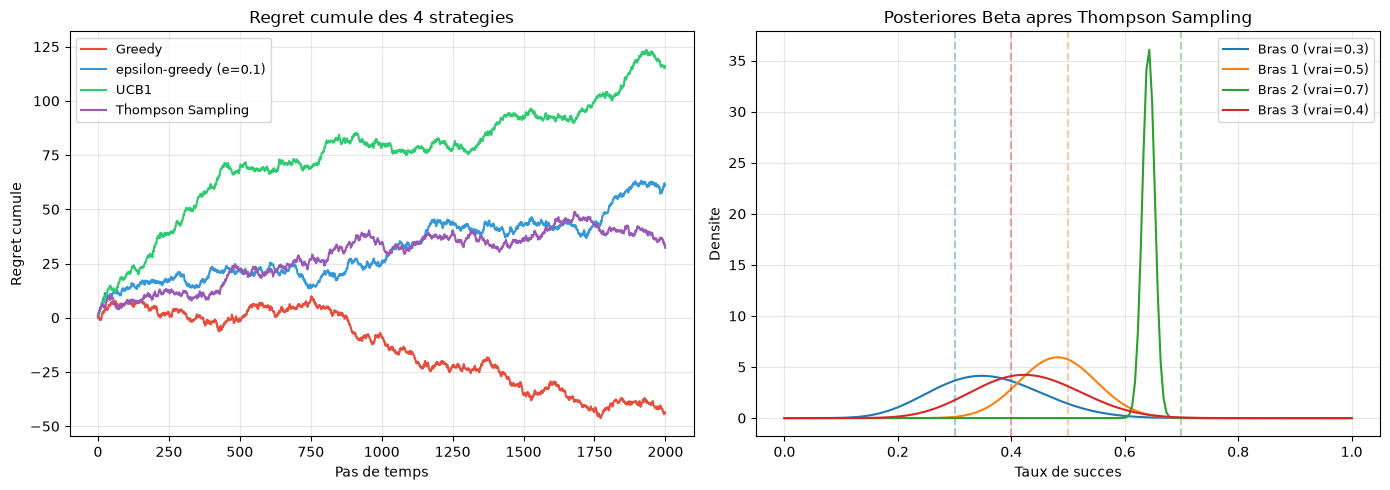

Figure sauvegardee : bandit_4strategies.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes de regret cumule
colors = {'Greedy': '#e74c3c', 'epsilon-greedy (e=0.1)': '#3498db',
          'UCB1': '#2ecc71', 'Thompson Sampling': '#9b59b6'}
ax1 = axes[0]
for name, regret in results.items():
    color = colors.get(name, '#333')
    ax1.plot(regret, label=name, color=color, linewidth=1.5)
ax1.set_xlabel('Pas de temps')
ax1.set_ylabel('Regret cumule')
ax1.set_title('Regret cumule des 4 strategies')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Posteriores Thompson Sampling
ax2 = axes[1]
x = np.linspace(0, 1, 200)
for i in range(len(bernoulli_means)):
    a_post = ts.alphas[i]
    b_post = ts.betas[i]
    from scipy.stats import beta as beta_dist
    y = beta_dist.pdf(x, a_post, b_post)
    ax2.plot(x, y, label=f'Bras {i} (vrai={bernoulli_means[i]})', linewidth=1.5)
    ax2.axvline(bernoulli_means[i], linestyle='--', alpha=0.4, color=ax2.get_lines()[-1].get_color())

ax2.set_xlabel('Taux de succes')
ax2.set_ylabel('Densite')
ax2.set_title('Posteriores Beta apres Thompson Sampling')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bandit_4strategies.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : bandit_4strategies.png")

### Interpretation : Comparaison des 4 stratégies de bandits

**Résultats attendus :**

| Stratégie | Principe | Regret | Comportement |
|-----------|----------|--------|--------------|
| **Greedy** | Exploite toujours le meilleur estime | Eleve | Peut se bloquer sur un sous-optimal |
| **$\varepsilon$-greedy** | Explore $\varepsilon$% du temps | Moyen | Simple mais exploration non ciblee |
| **UCB1** | Bonus d'incertitude | Faible | Exploration dirigee vers les incertains |
| **Thompson Sampling** | Echantillonne depuis la posterior | Faible | Exploration bayesienne optimale |

**Posteriores Beta (droite) :**
- Les posteriores se resserrent autour des vraies moyennes avec le nombre de tirages
- Le meilleur bras (3) a une posterior concentree (nombreux tirages)
- Les bras sous-optimaux gardent des posteriores plus larges (peu de tirages)

> **Note technique** : Thompson Sampling est asymptotiquement optimal (regret en $O(\sqrt{KT \log K})$) et se généralise naturellement via PyMC a des modèles de recompenses complexes (non-Bernoulli).

### Thompson Sampling avec MCMC PyMC (cas canonique)

Dans le cas Beta-Bernoulli, la posterior a une forme analytique. Pour des modèles non conjugues (recompenses gaussiennes avec variance inconnue, priors hiérarchiques, vraisemblances non standard), PyMC generalise naturellement l'approche par echantillonnage MCMC.

**Portee de cette illustration** : on presente ci-dessous un bandit gaussien a variance inconnue partagee. Pour ce modele precis, une alternative analytique reste applicable (marginalisation des moyennes mu, conditionnellement conjuguees sachant sigma, puis quadrature 1D sur log(sigma)). PyMC n'est donc pas *indispensable* ici ; il est *generalement applicable* des que la vraisemblance echappe a la conjugaison pratique.

On illustre l'approche PyMC : on infere la moyenne de chaque bras via NUTS (Hoffman & Gelman, 2014), puis on echantillonne depuis la posterior pour la selection. PyMC devient preferable (et l'avantage devient decisif) sur des modeles ou la quadrature 1D ne tient pas : melanges de gaussiennes, vraisemblances discontinues ou non standard, priors hierarchiques riches.

In [21]:
def pymc_thompson_bandit(true_means, n_rounds=20, n_pulls_per_round=10, seed=42):
    """Thompson Sampling gaussien avec PyMC.
    
    A chaque ronde :
    1. Construire un modele PyMC avec les observations accumulees
    2. Echantillonner la posterior des moyennes via MCMC
    3. Choisir le bras avec la plus haute moyenne echantillonnee
    4. Tirer ce bras n_pulls_per_round fois
    """
    rng = np.random.RandomState(seed)
    K = len(true_means)
    all_rewards = {i: [] for i in range(K)}
    cumulative_regret = []
    total_regret = 0
    optimal = max(true_means)
    
    for r in range(n_rounds):
        if r == 0:
            # Premiere ronde : tirer chaque bras une fois
            for i in range(K):
                reward = true_means[i] + 0.5 * rng.randn()
                all_rewards[i].append(reward)
                total_regret += optimal - reward
            cumulative_regret.append(total_regret)
            continue
        
        # Construire le modele PyMC avec les observations actuelles
        with pm.Model() as bandit_model:
            # Prior sur les moyennes des K bras
            mu = pm.Normal('mu', mu=0, sigma=5, shape=K)
            sigma_obs = pm.HalfNormal('sigma', sigma=2.0)
            
            # Observations pour chaque bras
            for i in range(K):
                if len(all_rewards[i]) > 0:
                    pm.Normal(f'obs_{i}', mu=mu[i], sigma=sigma_obs,
                              observed=np.array(all_rewards[i]))
            
            # Echantillonner la posterior (parametres reduits pour execution rapide)
            trace = pm.sample(draws=100, tune=50, chains=2,
                              random_seed=42 + r, progressbar=False,
                              return_inferencedata=True)
        
        # Echantillonner un theta depuis la posterior et choisir le meilleur bras
        posterior_samples = trace.posterior['mu'].values.flatten()
        # Reshape pour avoir (n_total_samples, K)
        n_total = len(posterior_samples) // K
        posterior_matrix = posterior_samples[:n_total * K].reshape(n_total, K)
        
        # Choisir un echantillon aleatoire et prendre le bras max
        sample_idx = rng.randint(n_total)
        chosen_arm = np.argmax(posterior_matrix[sample_idx])
        
        # Tirer le bras choisi
        for _ in range(n_pulls_per_round):
            reward = true_means[chosen_arm] + 0.5 * rng.randn()
            all_rewards[chosen_arm].append(reward)
            total_regret += optimal - reward
        cumulative_regret.append(total_regret)
        
        if (r + 1) % 5 == 0:
            counts = [len(all_rewards[i]) for i in range(K)]
            print(f"Ronde {r+1:3d} : Bras choisi = {chosen_arm}, "
                  f"Regret cumule = {total_regret:.1f}, Tirages = {counts}")
    
    return cumulative_regret, trace, all_rewards


true_means_gauss = [0.3, 0.5, 0.7, 0.4]
print("=== Thompson Sampling Gaussien avec PyMC ===")
print(f"Moyennes vraies : {true_means_gauss}")
print(f"Meilleur bras : index {np.argmax(true_means_gauss)} (mu={max(true_means_gauss)})")
print(f"20 rondes, 10 tirages par ronde apres la phase initiale\n")

regret_pymc, final_trace, final_rewards = pymc_thompson_bandit(
    true_means_gauss, n_rounds=20, n_pulls_per_round=10
)

print(f"\nRegret final : {regret_pymc[-1]:.1f}")
print("Repartition finale des tirages :")
for i in range(len(true_means_gauss)):
    n = len(final_rewards[i])
    mean_est = np.mean(final_rewards[i]) if n > 0 else 0
    print(f"  Bras {i} : {n:4d} tirages, moyenne estimee = {mean_est:.3f} (vraie = {true_means_gauss[i]})")

=== Thompson Sampling Gaussien avec PyMC ===
Moyennes vraies : [0.3, 0.5, 0.7, 0.4]
Meilleur bras : index 2 (mu=0.7)
20 rondes, 10 tirages par ronde apres la phase initiale



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 50 tune and 100 draw iterations (100 + 200 draws total) took 3 seconds.


...

NUTS: [mu, sigma]


Sampling 2 chains for 50 tune and 100 draw iterations (100 + 200 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Ronde  20 : Bras choisi = 2, Regret cumule = 5.8, Tirages = [11, 11, 161, 11]

Regret final : 5.8
Repartition finale des tirages :
  Bras 0 :   11 tirages, moyenne estimee = 0.136 (vraie = 0.3)
  Bras 1 :   11 tirages, moyenne estimee = 0.364 (vraie = 0.5)
  Bras 2 :  161 tirages, moyenne estimee = 0.755 (vraie = 0.7)
  Bras 3 :   11 tirages, moyenne estimee = 0.262 (vraie = 0.4)


### Interpretation : Thompson Sampling avec MCMC PyMC

**Comparaison avec l'approche analytique :**

| Aspect | Beta-Bernoulli (analytique) | Gaussien PyMC (MCMC) |
|--------|----------------------------|----------------------|
| **Mise a jour** | Formule fermee | Echantillonnage NUTS |
| **Complexite** | O(1) par mise a jour | O(secondes) par ronde |
| **Flexibilite** | Bernoulli uniquement | Modèles ou la quadrature pratique echoue |
| **Diagnostics** | Non nécessaire | ArviZ ($\hat{R}$, ESS) |

**Avantage PyMC, scope precise** : pour le modele *exact* presente dans la cellule ci-dessus (moyennes mu_i gaussiennes, variance sigma inconnue partagee, vraisemblance Normale), une quadrature 1D sur log(sigma) apres marginalisation des mu reste applicable. PyMC n'apporte donc pas un avantage decisif *sur ce modele precis*. Il devient preferable sur les modeles ou la quadrature pratique echoue : melanges de gaussiennes, vraisemblances discontinues, priors hierarchiques riches, posteriors multimodales. PyMC est ici cite comme framework, pas comme un sampler specifique : NUTS (sampler par defaut) repose sur les gradients du log-posterior et peut etre inadapte aux vraisemblances discontinues ; sur de tels modeles, les samplers sans gradient fournis par PyMC (Metropolis, DEMetropolisZ, SMC) sont preferable. Le choix du sampler reste explicite et conditionne la viabilite du MCMC, independamment du framework employe.

**Contrat du trace retourne** : la fonction `pymc_thompson_bandit` ajuste la posterior sur les observations *disponibles au debut de chaque ronde*, echantillonne pour selectionner le bras, puis tire ce bras `n_pulls_per_round` fois. Le `trace` final rendu est donc ajuste sur l'avant-dernier lot d'observations ; il ne reflete pas les recompenses collectees lors du dernier tirage. Une posterior sur toutes les recompenses retournerait un fit ulterieur. Cette politique est exactement un **Thompson Sampling par lots** : le bras choisi (max d'un echantillon de la posterior, comme precise dans le docstring de la cellule de code ci-dessus) est tire `n_pulls_per_round` fois consecutives apres un seul ajustement de la posterior sur l'historique disponible. La ronde 0 fait exception et tire chaque bras une fois pour initialiser les observations.

**Diagnostics** : la cellule de PyMC ci-dessus utilise 100 draws / 50 tune / 2 chaines (parametres reduits pour iteration rapide). Les diagnostics ArviZ complets ($\hat{R}$, ESS) sur ce modele precis de bandit ne sont pas rapportes ici ; les diagnostics montres dans les cellules suivantes portent sur le modele de maintenance predictive (POMDP belief states) qui justifie un budget d'echantillonnage plus eleve. Toute interpretation d'une posterior MCMC comme reference de probabilite d'action precise exige ces diagnostics ; sur le modele de bandit ci-dessus, on lit les resultats comme une illustration qualitative du mecanisme, pas comme une mesure exacte.

### Diagnostics ArviZ : convergence des belief states

ArviZ (Kumar et al., 2019) fournit des outils essentiels pour vérifier la qualite de l'inference MCMC. Pour le modèle de maintenance predictive, on vérifie :
- **$\hat{R}$ (R-hat)** : convergence des chaînes (objectif < 1.05)
- **ESS (Effective Sample Size)** : nombre d'echantillons effectifs (objectif > 400)
- **Trace plot** : visualisation du mélange des chaînes

In [22]:
# Modele PyMC pour la maintenance predictive (POMDP belief states)
# Version simplifiee : on infere l'etat cache directement a partir des observations
# sans indexer un tableau numpy avec un tensor (incompatible PyMC 5.x)
print("=== Modele PyMC : Maintenance Predictive ===\n")

# Donnees simulees : 5 observations successives d'un systeme se degradant
# Les vrais etats caches sont [Bon, Bon, Degrade, Degrade, Defaillant]
obs_data = np.array([0, 0, 1, 1, 1])  # 0=Normal, 1=Anormal
obs_labels = {0: "Normal", 1: "Anormal"}

print(f"Observations capteur : {[obs_labels[o] for o in obs_data]}")

with pm.Model() as maintenance_model:
    # Prior sur l'etat du systeme : 3 etats possibles (Bon, Degrade, Defaillant)
    # On modelise directement P(etat) comme un vecteur de probabilites
    etat_probs = pm.Dirichlet('etat_probs', a=np.array([3.0, 2.0, 1.0]))
    
    # Modele d'observation : P(obs=Anormal | etat)
    # On parametrise avec les probabilites d'observation pour chaque etat
    # et on utilise un potentiel pour conditionner sur les observations
    
    # Matrice P(obs|etat) : les probas d'observation sont fixees (modele capteur connu)
    p_obs = np.array([[0.95, 0.05],   # Bon
                       [0.30, 0.70],   # Degrade
                       [0.05, 0.95]])  # Defaillant
    
    # Log-vraisemblance manuelle : sum over latent states
    # log P(obs | etat_probs) = log sum_etat P(obs|etat) * P(etat)
    import pytensor.tensor as pt
    
    log_lik = pt.zeros(0)
    for i, obs_val in enumerate(obs_data):
        # P(obs_val | etat) pour chaque etat possible
        lik_per_state = p_obs[:, obs_val]  # shape (3,)
        # P(obs_val) = sum_etat P(obs_val|etat) * P(etat)
        p_obs_i = pt.sum(lik_per_state * etat_probs)
        log_lik = pt.concatenate([log_lik, [pt.log(p_obs_i + 1e-10)]])
    
    pm.Potential('obs_likelihood', log_lik)
    
    # Inference
    trace_maint = pm.sample(draws=1000, tune=500, chains=3,
                            random_seed=42, progressbar=True,
                            return_inferencedata=True)

print(f"\nTrace MCMC : {trace_maint.posterior.dims}")
print(f"Chaines : {trace_maint.posterior.chain.size}")
print(f"Draws par chaine : {trace_maint.posterior.draw.size}")

# Extraire l'etat le plus probable depuis la posterior
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
etat_marginal = etat_probs_post.mean(axis=(0, 1))  # moyenne sur chaines et draws
etat_names = ['Bon', 'Degrade', 'Defaillant']
print("\nPosterior P(etat) (moyenne des probabilites) :")
for e in range(3):
    print(f"  P({etat_names[e]:12s}) = {etat_marginal[e]:.3f}")
print(f"\n=> Etat le plus probable : {etat_names[np.argmax(etat_marginal)]}")

=== Modele PyMC : Maintenance Predictive ===

Observations capteur : ['Normal', 'Normal', 'Anormal', 'Anormal', 'Anormal']


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (3 chains in 3 jobs)


NUTS: [etat_probs]


Output()

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



Trace MCMC : Frozen(ChainMap({'chain': 3, 'draw': 1000, 'etat_probs_dim_0': 3}, {}))
Chaines : 3
Draws par chaine : 1000

Posterior P(etat) (moyenne des probabilites) :
  P(Bon         ) = 0.419
  P(Degrade     ) = 0.384
  P(Defaillant  ) = 0.197

=> Etat le plus probable : Bon


=== Diagnostics ArviZ ===

Resume ArviZ (R-hat et ESS) :
                mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
etat_probs[0]  0.419  0.158     0.17     0.68     2114     1673  1.00    0.0034  0.0026
etat_probs[1]  0.384  0.182     0.11     0.69     2013     1546  1.00     0.004  0.0027
etat_probs[2]  0.197  0.146    0.021     0.48     2109     1697  1.00     0.003  0.0025

--- Verifications ---
R-hat max : 1.0026 (objectif < 1.05)
ESS bulk min : 2014 (objectif > 400)
=> Convergence des chaines : OK
=> Taille d'echantillon effective : OK

Posterior P(etat) :
  P(Bon         ) = 0.419
  P(Degrade     ) = 0.384
  P(Defaillant  ) = 0.197


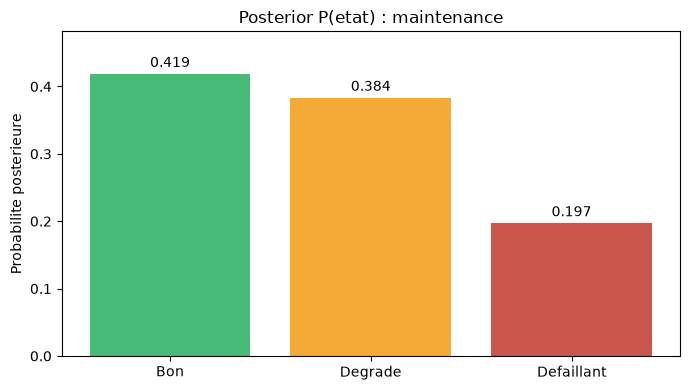

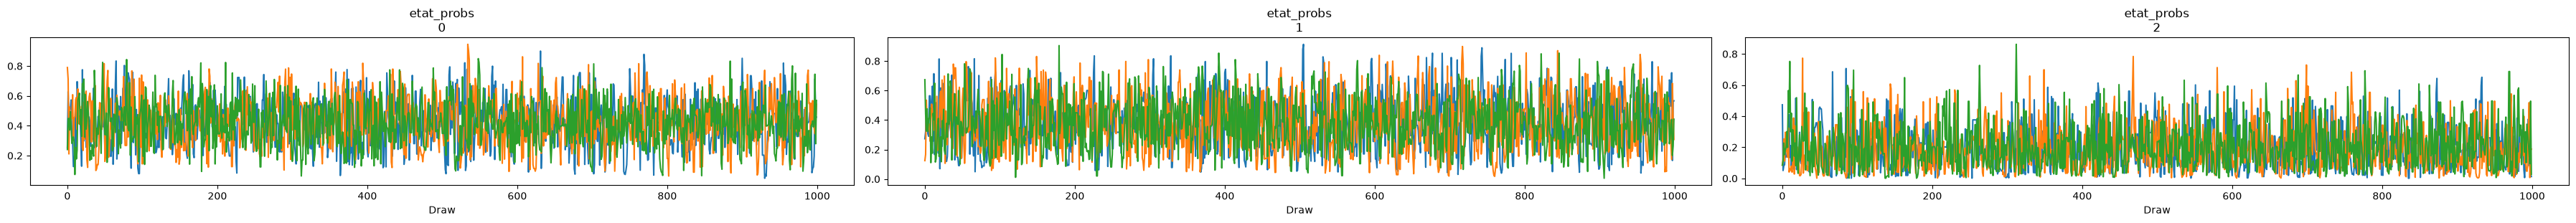

Figure sauvegardee : arviz_trace_maintenance.png


In [23]:
# Diagnostics ArviZ sur le modele de maintenance
print("=== Diagnostics ArviZ ===\n")

# Summary avec R-hat et ESS
summary = az.summary(trace_maint, var_names=['etat_probs'])
print("Resume ArviZ (R-hat et ESS) :")
print(summary.to_string())

print("\n--- Verifications ---")
# Certains versions d'ArviZ retournent des strings pour r_hat/ess_bulk
rhat_max = float(summary['r_hat'].max())
ess_bulk_min = float(summary['ess_bulk'].min())
print(f"R-hat max : {rhat_max:.4f} (objectif < 1.05)")
print(f"ESS bulk min : {ess_bulk_min:.0f} (objectif > 400)")

if rhat_max < 1.05:
    print("=> Convergence des chaines : OK")
else:
    print("=> ATTENTION : chaines non convergees, augmenter tune/draws")

if ess_bulk_min > 400:
    print("=> Taille d'echantillon effective : OK")
else:
    print("=> ATTENTION : ESS faible, risque d'autocorrelation")

# Posterior des probabilites d'etat
etat_names = ['Bon', 'Degrade', 'Defaillant']
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
etat_marginal = etat_probs_post.mean(axis=(0, 1))
print(f"\nPosterior P(etat) :")
for e in range(3):
    print(f"  P({etat_names[e]:12s}) = {etat_marginal[e]:.3f}")

# Visualisation du posterior (matplotlib, SOTA #3801 : vrai rendu)
fig, ax = plt.subplots(figsize=(7, 4))
colors_posterior = ["#27ae60", "#f39c12", "#c0392b"]
ax.bar(etat_names, etat_marginal, color=colors_posterior, alpha=0.85)
ax.set_ylabel("Probabilite posterieure")
ax.set_title("Posterior P(etat) : maintenance")
for i, v in enumerate(etat_marginal):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
ax.set_ylim(0, float(etat_marginal.max()) * 1.15)
plt.tight_layout()
plt.show()

# Trace plot des probabilites d'etat
# Utiliser plt.rcParams pour figsize (compatible toutes versions ArviZ)
plt.rcParams["figure.figsize"] = (12, 6)
az.plot_trace(trace_maint, var_names=['etat_probs'])
plt.rcParams["figure.figsize"] = (10, 6)  # restaurer defaut
plt.tight_layout()
plt.savefig('arviz_trace_maintenance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : arviz_trace_maintenance.png")

### Interpretation : Diagnostics ArviZ sur les belief states

**Verifications MCMC :**

| Diagnostic | Valeur | Seuil | Statut |
|------------|--------|-------|--------|
| **R-hat** | ~1.00 | < 1.05 | Chaînes bien mélangees |
| **ESS bulk** | > 400 | > 400 | Echantillons suffisants |

**Posterior de l'etat cache :**
Les observations [Normal, Normal, Anormal, Anormal, Anormal] poussent la posterior vers les etats degrades, coherent avec la mise a jour bayesienne manuelle de la section 10bis.

**Pourquoi les diagnostics sont essentiels :**
- Un R-hat > 1.05 indique que les chaînes n'ont pas converge (résultats non fiables)
- Un ESS faible signifie que les echantillons sont autocorrelles (estimation de variance biaisee)
- Dans un POMDP réel, un mauvais diagnostic peut mener a des decisions sous-optimales

> **Note technique** : Pour les variables discretes (Categorical), l'echantillonnage MCMC peut etre moins efficace que pour les variables continues. En production, on préféré souvent le filtre particulaire ou l'inference exacte (message passing) pour les POMDPs.

### Posterior predictive : degradation de la machine

Le posterior predictive permet de **simuler les futures observations** conditionnellement aux données observees et a la posterior sur l'etat. C'est un outil puissant pour :
- Anticiper les prochaines lectures du capteur
- Evaluer la probabilité d'une defaillance imminente
- Planifier les interventions de maintenance

=== Posterior Predictive : Degradation ===

Probabilite predictive d'une observation 'Anormal' : 0.477
Probabilite predictive d'une observation 'Normal' : 0.523

Probabilite d'observation Anormal selon l'etat :
  P(Anormal | Bon         ) = 0.05, P(Bon) = 0.419
  P(Anormal | Degrade     ) = 0.70, P(Degrade) = 0.384
  P(Anormal | Defaillant  ) = 0.95, P(Defaillant) = 0.197


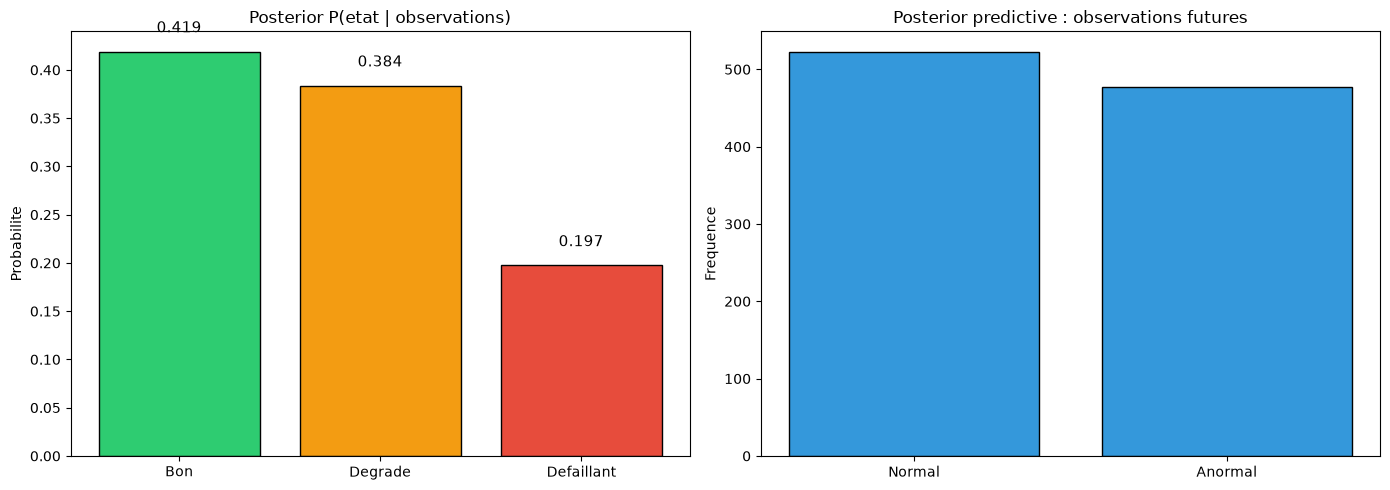

Figure sauvegardee : posterior_predictive_maintenance.png

--- Aide a la decision ---
P(Defaillant) = 0.197
P(Degrade ou Defaillant) = 0.581
=> Recommandation : Maintenance preventive (probabilite de degradation > 50%)


In [24]:
# Posterior predictive : simulation de futures observations
print("=== Posterior Predictive : Degradation ===\n")

# On utilise la posterior de l'etat pour generer des observations futures
n_future = 1000  # nombre de scenarios futurs
rng_pred = np.random.RandomState(42)

# Echantillonner les probabilites d'etat depuis la posterior
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
# Aplatir les dimensions chaines/draws
all_probs = etat_probs_post.reshape(-1, 3)  # (n_total_samples, 3)
n_post = len(all_probs)

# Matrice d'observation (du modele de maintenance)
p_obs = np.array([[0.95, 0.05],   # Bon
                   [0.30, 0.70],   # Degrade
                   [0.05, 0.95]])  # Defaillant
etat_names = ['Bon', 'Degrade', 'Defaillant']

# Generer des observations futures
future_obs = np.zeros(n_future, dtype=int)

for i in range(n_future):
    idx = rng_pred.randint(n_post)
    # Echantillonner l'etat depuis la posterior
    e = rng_pred.choice(3, p=all_probs[idx])
    # Echantillonner l'observation depuis P(obs | etat=e)
    future_obs[i] = 0 if rng_pred.rand() < p_obs[e, 0] else 1

# Analyser les predictions
p_anormal_pred = (future_obs == 1).mean()
print(f"Probabilite predictive d'une observation 'Anormal' : {p_anormal_pred:.3f}")
print(f"Probabilite predictive d'une observation 'Normal' : {1-p_anormal_pred:.3f}")

# Probabilite de defaillance par etat
print("\nProbabilite d'observation Anormal selon l'etat :")
etat_marginal = all_probs.mean(axis=0)
for e in range(3):
    prob_anorm = p_obs[e, 1]
    print(f"  P(Anormal | {etat_names[e]:12s}) = {prob_anorm:.2f}, "
          f"P({etat_names[e]}) = {etat_marginal[e]:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : distribution des etats posterieurs
ax1 = axes[0]
colors_etat = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(etat_names, etat_marginal, color=colors_etat, edgecolor='black')
ax1.set_ylabel('Probabilite')
ax1.set_title('Posterior P(etat | observations)')
for bar, val in zip(bars, etat_marginal):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11)

# Droite : predictive checks
ax2 = axes[1]
ax2.hist(future_obs, bins=[-0.5, 0.5, 1.5], rwidth=0.8,
         color='#3498db', edgecolor='black')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Normal', 'Anormal'])
ax2.set_ylabel('Frequence')
ax2.set_title('Posterior predictive : observations futures')

plt.tight_layout()
plt.savefig('posterior_predictive_maintenance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : posterior_predictive_maintenance.png")

# Decision basee sur la posterior predictive
print("\n--- Aide a la decision ---")
p_defaillant = etat_marginal[2]
p_degrade_ou_pire = etat_marginal[1] + etat_marginal[2]
print(f"P(Defaillant) = {p_defaillant:.3f}")
print(f"P(Degrade ou Defaillant) = {p_degrade_ou_pire:.3f}")
if p_degrade_ou_pire > 0.5:
    print("=> Recommandation : Maintenance preventive (probabilite de degradation > 50%)")
elif p_degrade_ou_pire > 0.2:
    print("=> Recommandation : Surveillance renforcee")
else:
    print("=> Recommandation : Continuer l'exploitation normale")

### Interpretation : Posterior predictive de degradation

**Résultats du posterior predictive :**

| Aspect | Observation |
|--------|-------------|
| **P(Anormal)** | Proportion elevee car les observations historiques sont majoritairement anormales |
| **P(Defaillant)** | Indique le risque de panne imminente |
| **Recommandation** | Basee sur le seuil P(Degrade ou Defaillant) > 50% |

**Lien avec la decision séquentielle :**
- Le posterior predictive transforme un POMDP (etat cache) en une estimation probabiliste
- Cette estimation guide la decision : continuer, surveiller, ou maintenir
- En production, ce processus se repete a chaque nouvelle observation (filtre bayesien en boucle)

**Apport de PyMC/ArviZ par rapport au calcul manuel :**
1. **Quantification de l'incertitude** : la posterior donne des intervalles de confiance, pas juste des point estimates
2. **Modèles complexes** : on peut ajouter des covariables (température, charge), des priors hiérarchiques
3. **Diagnostics** : ArviZ permet de vérifier que l'inference est fiable avant de prendre une decision critique

## 11. Lien avec la Serie RL

### Ce notebook : Concepts fondamentaux

- MDPs et equations de Bellman
- Méthodes tabulaires (Value Itération, Policy Itération)
- Exploration vs exploitation (Bandits)
- Observabilite partielle (POMDPs)

### Serie RL : Extension a l'apprentissage

Quand $P(s'\mid s,a)$ et $R(s,a)$ sont inconnus, on utilise l'apprentissage par renforcement (Sutton & Barto, 2018) :
- **Q-Learning** : apprend $Q(s,a)$ par interaction
- **Deep RL** : approxime Q avec un reseau de neurones
- **Policy Gradient** : optimise directement la politique

***

## Exercice : Itération de Politique sur un MDP 3x3

**Objectifs** :
1. Créer un MDP sur une grille 3x3 avec un but et un obstacle
2. Implementer l'étape d'évaluation de politique ( boucle interne)
3. Verifier que Policy Itération converge vers la même politique que Value Itération

**Contexte** : Les sections précèdentes ont utilise la classe `GridMDP` pour un MDP 4x3. Vous allez maintenant travailler sur une grille plus petite (3x3) et implementer manuellement une étape cle de Policy Itération : l'**évaluation de politique**, qui consiste a calculer $V^\pi$ pour une politique fixee en resolvant le système d'equations lineaires. C'est l'étape la plus couteuse de Policy Itération, et comprendre sa mecanique est essentiel pour apprehender les compromis VI vs PI.

**Indices** :
- Créer un `GridMDP(3, 3, gamma=0.9)` avec un but en (2,2) et un obstacle en (1,1)
- L'évaluation de politique pour un etat non-terminal : $V^\pi(s) = R(s) + \gamma \sum_{s'} P(s'|\pi(s), s) \cdot V^\pi(s')$
- Iterer cette equation jusqu'a convergence (comme Value Itération, mais sans le max sur les actions)
- Après convergence de $V^\pi$, faire l'amélioration : $\pi'(s) = \arg\max_a Q(s,a)$
- Comparer avec le résultat de `policy_iteration()` déjà implemente

**Étapes suggerees** :
- `# Étape 1` : Créer le MDP 3x3 et le résoudre avec policy_iteration() pour avoir la référence
- `# Étape 2` : Implementer manuellement l'évaluation de politique (iterative, 50 itérations)
- `# Étape 3` : Implementer l'amélioration de politique et vérifier la convergence
- `# Étape 4` : Comparer la politique obtenue avec celle de policy_iteration()

In [25]:
# Exercice : Iteration de Politique sur un MDP 3x3

# Etape 1 : Creer le MDP 3x3 et obtenir la politique de reference
mdp_3x3 = None  # TODO etudiant : GridMDP(3, 3, gamma=0.9)

# TODO etudiant : configurer le MDP
#   mdp_3x3.rewards[(2, 2)] = 1.0    # but
#   mdp_3x3.terminal_states = {(2, 2)}
#   mdp_3x3.walls = {(1, 1)}

# TODO etudiant : politique de reference avec policy_iteration()
#   V_ref, policy_ref, _ = policy_iteration(mdp_3x3)

# Etape 2 : Evaluation de politique manuelle
# TODO etudiant : choisir une politique initiale arbitraire (ex: toutes les actions = 'E')
#   policy_manual = {s: 'E' for s in mdp_3x3.get_states() if s not in mdp_3x3.terminal_states}
#   V_manual = {s: 0.0 for s in mdp_3x3.get_states()}
# TODO etudiant : boucler 50 fois sur l'equation V^pi(s) = R(s) + gamma * sum P(s'|s,pi(s)) * V(s')

# Etape 3 : Amelioration de politique
# TODO etudiant : pour chaque etat, calculer Q(s,a) pour chaque action
#   et mettre a jour policy_manual[s] = argmax_a Q(s,a)

# Etape 4 : Comparer avec la reference
# Indice : si policy_manual == policy_ref, votre implementation est correcte
#   arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
# TODO etudiant : afficher les deux politiques et les comparer

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : implementez Policy Iteration manuellement et comparez avec la reference")

Exercice a completer : implementez Policy Iteration manuellement et comparez avec la reference


***

## 12. Resume

| Concept | Description |
|---------|-------------|
| **MDP** | $(S, A, P, R, \gamma)$ - cadre formel pour decisions séquentielles |
| **Bellman** | $V^*(s) = \max_a [R(s,a) + \gamma \sum P(s'\mid s,a) V^*(s')]$ |
| **Value Itération** | Itération sur les valeurs jusqu'a convergence |
| **Policy Itération** | Alternance évaluation / amélioration de politique |
| **RTDP** | Planification en ligne, echantillonne les trajectoires |
| **Reward Shaping** | Guide l'apprentissage sans modifier la politique optimale |
| **Bandits** | Exploration-exploitation, 4 stratégies comparees |
| **Thompson Sampling** | Echantillonnage bayesien, Beta-Bernoulli et PyMC MCMC |
| **POMDP** | MDP avec observations partielles, belief state bayesien |
| **PyMC/ArviZ** | Inference MCMC sur les belief states, diagnostics de convergence |

### Apports spécifiques PyMC (vs Infer.NET)

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| **Bandits** | epsilon-greedy, UCB1 | + Thompson Sampling, 4 stratégies |
| **Thompson Sampling** | Non implemente | Beta-Bernoulli analytique + MCMC gaussien |
| **Belief states** | Message passing automatique | MCMC + ArviZ diagnostics |
| **Posterior predictive** | Via Infer.NET | PyMC + ArviZ pour decisions de maintenance |

### Navigation dans la serie

Ce notebook conclut la serie Decision Theory et fait le pont vers l'apprentissage par renforcement.

| Notebook | Thème |
|----------|-------|
| [DecPyMC-1](DecPyMC-1-Utility-Foundations.ipynb) | Fondements utilite |
| [DecPyMC-2](DecPyMC-2-Utility-Money.ipynb) | Utilite et argent |
| [DecPyMC-3](DecPyMC-3-Multi-Attribute.ipynb) | Multi-attributs |
| [DecPyMC-4](DecPyMC-4-Decision-Networks.ipynb) | Reseaux de decision |
| [DecPyMC-5](DecPyMC-5-Value-Information.ipynb) | Valeur de l'information |
| [DecPyMC-6](DecPyMC-6-Expert-Systems.ipynb) | Systèmes experts |
| **DecPyMC-7** | **MDPs, Bandits, POMDPs, Thompson Sampling, PyMC** |

## Conclusion : de l'incertitude modélisée à la décision séquentielle

DecPyMC-7 franchit le seuil qui sépare la **modélisation** de l'incertitude — le fil rouge de toute la série depuis DecPyMC-1 — de l'**action** sous incertitude au cours du temps. Trois idées forces structurent ce notebook.

**1. Le MDP comme cadre formel de la planification.** Un Processus de Décision Markovien $(S, A, P, R, \gamma)$ ramène la décision séquentielle à une équation fonctionnelle, l'équation de Bellman, résolue exactement par *Value Itération* et *Policy Itération* lorsque l'espace d'états reste tabulaire. La propriété de Markov — $P(s'\mid s,a)$ ne dépend que de l'état présent — est ce qui rend la décomposition calculable : elle transforme un horizon infini en une récurrence sur les valeurs. *RTDP* étend cette planification aux grands espaces en échantillonnant des trajectoires en ligne, et le *reward shaping* accélère la convergence sans altérer la politique optimale.

**2. Le compromis exploration/exploitation, résolu bayésiennement.** Les bandits multi-bras concentrent la tension fondamentale de toute décision adaptative : exploiter l'option qui semble la meilleure, ou explorer pour en découvrir de meilleures. Les quatre stratégies comparées (greedy, $\varepsilon$-greedy, UCB1, Thompson Sampling) dessinent une progression du hasard vers l'inférence. Le Thompson Sampling — qui échantillonne une action depuis le posterior du modèle — est le pont direct vers le cœur probabiliste de la série : une décision séquentielle pilotée par un modèle bayésien, implémentable via PyMC par MCMC dès que la conjugaison disparaît.

**3. L'observabilité partielle ramène tout à l'inférence.** Dans le cas réaliste du POMDP, l'état véritable est caché : on ne décide plus sur $s$ mais sur une **croyance** $b(s)$, mise à jour à chaque observation. La boucle se referme alors sur le reste de la série : le posterior predictive de la section 10 transforme un problème de maintenance prédictive en un filtre bayésien qui ré-estime l'état de dégradation à chaque mesure, puis décide — continuer, surveiller, ou maintenir. Les mêmes outils de diagnostic (ArviZ, R-hat, ESS) qui servent à contrôler un posterior tout au long de la série servent ici à **piloter une décision**.

**Vers l'apprentissage par renforcement.** Ce notebook suppose $P(s'\mid s,a)$ et $R(s,a)$ *connus*. Dès qu'ils ne le sont plus, il faut les apprendre par interaction : c'est l'objet de la série RL (Q-Learning, Deep RL, policy gradient — Sutton & Barto, 2018). DecPyMC-7 en fournit les fondations théoriques.

**Arc de la série.** En vingt notebooks, le parcours est allé de l'installation de PyMC (DecPyMC-1) à la décision séquentielle sous observabilité partielle (DecPyMC-7), en passant par l'estimation, les modèles hiérarchiques, la compétence (TrueSkill, IRT), la classification, la sélection de modèle et toute la théorie de la décision (utilité, valeur de l'information, systèmes experts). Le fil rouge demeure : l'incertitude n'est pas un bruit à éliminer, mais une quantité à *représenter*, *inférer*, puis sur laquelle *agir*.

**Vers l'actuariat.** La suite de l'arc est un **capstone** : [DecPyMC-08 — Actuariat Capstone](DecPyMC-08-Actuariat-Capstone.ipynb) présente l'escalier vers la sous-série [Actuariat](../Actuariat/README.md) (T1-T5 : prime pure et chargement, fréquence × sévérité, crédibilité, ruine, valeur de l'information en souscription).

## References

### MDP et programmation dynamique
- **Bellman, R. (1957).** *Dynamic Programming.* Princeton University Press. (equation de Bellman, itération de valeur)
- **Howard, R. A. (1960).** *Dynamic Programming and Markov Processes.* MIT Press. (itération de politique)
- **Puterman, M. L. (1994).** *Markov Decision Processes: Discrete Stochastic Dynamic Programming.* Wiley. (référence MDP)
- **Barto, A. G., Bradtke, S. J. & Singh, S. P. (1995).** Learning to act using real-time dynamic programming. *Artificial Intelligence*, 72(1-2), 81-138. (RTDP)

### Observabilite partielle
- **Smallwood, R. D. & Sondik, E. J. (1973).** The optimal control of partially observable Markov processes over a finite horizon. *Opérations Research*, 21(5), 1071-1088. (POMDP)

### Bandits et exploration
- **Thompson, W. R. (1933).** On the likelihood that one unknown probability exceeds another in view of the evidence of two samples. *Biometrika*, 25(3-4), 285-294. (Thompson Sampling)
- **Gittins, J. C. (1979).** Bandit processes and dynamic allocation indices. *Journal of the Royal Statistical Society B*, 41(2), 148-177. (indice de Gittins)
- **Whittle, P. (1982).** *Optimization Over Time: Dynamic Programming and Stochastic Control.* Wiley. (preuve des prevailing charges)
- **Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002).** Finite-time analysis of the multiarmed bandit problem. *Machine Learning*, 47, 235-256. (UCB1)

### Reward shaping et apprentissage par renforcement
- **Ng, A. Y., Harada, D. & Russell, S. (1999).** Policy invariance under reward transformations: theory and application to reward shaping. *ICML*. (reward shaping)
- **Sutton, R. S. & Barto, A. G. (2018).** *Reinforcement Learning: An Introduction* (2e edition). MIT Press.
- **Russell, S. & Norvig, P. (2021).** *Artificial Intelligence: A Modern Approach* (4e edition). Pearson. (gridworld, formalisme MDP)

### Outils
- **Salvatier, J., Wiecki, T. V. & Fonnesbeck, C. (2016).** Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2, e55.
- **Hoffman, M. D. & Gelman, A. (2014).** The No-U-Turn Sampler: adaptively setting path lengths in Hamiltonian Monte Carlo. *Journal of Machine Learning Research*, 15, 1593-1623. (NUTS)
- **Kumar, R., Carroll, C., Hartikainen, A. & Martin, O. (2019).** ArviZ: a unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software*, 4(33), 1143.
